# Actividad 03 · Algoritmo genético en siete etapas para seleccionar una cartera de proyectos

| | |
|---|---|
| **Alumno** | Víctor Manuel Santos Martínez — matrícula 253220020 |
| **Materia** | Algoritmos Evolutivos — Maestría en Inteligencia Artificial |
| **Docente** | Dr. Jaime Aguilar Ortiz |
| **Actividad** | Actividad 03 — Aplicación de un algoritmo genético con la metodología de siete etapas |
| **Periodo** | Septiembre–diciembre de 2026 · Corte 1 |
| **Institución** | Universidad Politécnica Metropolitana de Hidalgo |

**Consigna.** *Desarrollar una aplicación de algoritmo genético aplicando la metodología de 7 etapas analizadas en clase. Para cada etapa elegir uno de los métodos propuestos y justificar la elección.* El informe debe describir el problema, definir el objetivo del estudio, definir el método de cada etapa, generar un código que apoye el objetivo, interpretar los resultados y anexar referencias.

**Qué hace este cuadernillo.** Formula un problema empresarial —la selección de una cartera de proyectos indivisibles con presupuesto de capital, horas-persona limitadas, dependencias y exclusiones—, lo resuelve con un algoritmo genético que toma **un método de la guía de los treinta métodos por cada etapa** y somete el resultado a cuatro contrastes: una referencia exacta, una heurística voraz, una búsqueda aleatoria con el mismo presupuesto de evaluaciones y una variante de la etapa de evaluación.

| Etapa | Método elegido | Función |
|---|---|---|
| 1. Inicialización | **M02** Bernoulli | `etapa_1_inicializar_M02` |
| 2. Evaluación | **M08** prioridad de factibilidad | `etapa_2_evaluar` |
| 3. Selección | **M12** torneo con reemplazo | `etapa_3_seleccionar_M12` |
| 4. Recombinación | **M14** cruce uniforme por máscara | `etapa_4_recombinar_M14` |
| 5. Mutación | **M17** inversión de bits | `etapa_5_mutar_M17` |
| 6. Reemplazo | **M22** generacional con elitismo | `etapa_6_reemplazar_M22` |
| 7. Criterio de paro | **M28** estancamiento | `etapa_7_parar_M28` |

**Orden de lectura.** A, entorno · B, modelo · C, referencias y líneas base · D, las siete etapas · E, pruebas · F, instancias · G, calibración · H, evaluación · I, ablación de la etapa 2 · J, caso principal · K, figuras · L, manifiesto · M, lectura de resultados.

Todos los datos son **sintéticos**: no proceden de una empresa real, y los valores en millones de pesos son una escala de trabajo, no una estimación financiera.

## A. Entorno y dependencias

### A.1 Comprobación del entorno

La primera celda falla de inmediato si el kernel no pertenece al entorno conda `science`. El nombre visible del kernel no basta: se comprueba la ruta del intérprete que realmente ejecuta el código.

In [1]:
import sys
import platform
from pathlib import Path

if "envs/science" not in sys.executable.replace("\\", "/"):
    raise RuntimeError(
        f"Este cuadernillo debe ejecutarse con el entorno conda 'science'. Intérprete actual: {sys.executable}"
    )
print("Intérprete:", sys.executable)
print("Python", platform.python_version(), "·", platform.platform())
print("Directorio de trabajo:", Path.cwd())

Intérprete: /opt/homebrew/Caskroom/miniconda/base/envs/science/bin/python3.11
Python 3.11.16 · macOS-27.0.1-arm64-arm-64bit
Directorio de trabajo: /Users/victormanuel/Library/Mobile Documents/com~apple~CloudDocs/Maestría UMPH/Cuatrimestre 4/Algoritmos Evolutivos/Actividades/Actividad 3


### A.2 Dependencias, constantes y estilo de las figuras

Sólo bibliotecas generales: NumPy para el cálculo vectorizado, pandas para las tablas, Matplotlib para las figuras y SciPy para dos tareas que **no** forman parte del algoritmo genético: el solucionador exacto de programación entera (HiGHS, mediante `scipy.optimize.milp`) y la prueba de rangos con signo de Wilcoxon. No se usa ninguna biblioteca especializada en algoritmos genéticos.

Las unidades se guardan como **enteros** para que la factibilidad y la coincidencia con el óptimo se decidan sin tolerancias numéricas: la inversión en décimas de millón de pesos, las horas-persona como enteros y el valor en centésimas de millón.

In [2]:
import ctypes
import hashlib
import json
import os
import time
from contextlib import contextmanager
from dataclasses import dataclass

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.stats import wilcoxon

ESCALA_INVERSION = 10    # décimas de millón de pesos
ESCALA_VALOR = 100       # centésimas de millón de pesos
RESULTADOS = Path("resultados")
FIGURAS = Path("figuras")
RESULTADOS.mkdir(exist_ok=True)
FIGURAS.mkdir(exist_ok=True)
INICIO_CUADERNILLO = time.perf_counter()

# Paleta categórica validada (azul, naranja, aqua) y tinta de los gráficos.
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA_2, TENUE = "#0b0b0b", "#52514e", "#898781"
REJILLA, EJE, GRIS_CLARO = "#e1e0d9", "#c3c2b7", "#d9d8d2"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.edgecolor": EJE, "axes.linewidth": 0.8, "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2.0,
})
print("NumPy", np.__version__, "· pandas", pd.__version__, "· SciPy", scipy.__version__,
      "· Matplotlib", matplotlib.__version__)

NumPy 2.4.6 · pandas 3.0.6 · SciPy 1.17.1 · Matplotlib 3.11.2


## B. Modelo del problema

Una empresa dispone de $d$ proyectos candidatos. Cada proyecto $j$ requiere una inversión $c_j$ y $h_j$ horas-persona del equipo interno, y aporta un valor esperado $v_j$. La decisión es binaria: $x_j = 1$ si el proyecto entra en la cartera y $x_j = 0$ si no. Los proyectos son **indivisibles**: no se financia medio proyecto.

$$\max_{x \in \{0,1\}^d} \; z(x) = \sum_{j=1}^{d} v_j x_j \qquad\Longleftrightarrow\qquad \min_{x} J(x) = -z(x)$$

sujeto a

$$g_1(x)=\frac{\sum_j c_j x_j - B}{B}\le 0, \qquad g_2(x)=\frac{\sum_j h_j x_j - H}{H}\le 0,$$

$$x_j - x_i \le 0 \;\;\text{para cada dependencia } (i \to j), \qquad x_a + x_b - 1 \le 0 \;\;\text{para cada exclusión } \{a,b\}.$$

La convención de la guía es **minimizar**; por eso el valor se maximiza a través de $J=-z$. Las dos restricciones de recursos se escriben normalizadas por su capacidad para que un exceso del 10 % pese lo mismo en dinero que en horas. Con ellas se define la **violación agregada**

$$V(x)=\max\{0,g_1(x)\}+\max\{0,g_2(x)\}+\sum_{(i\to j)}\max\{0,x_j-x_i\}+\sum_{\{a,b\}}\max\{0,x_a+x_b-1\},$$

que vale cero exactamente en el conjunto factible $\Omega$. Es la medida que usará la etapa 2.

### B.1 Estructura de datos y validación

Una instancia se representa con una clase de datos inmutable. La validación rechaza datos imposibles en lugar de corregirlos en silencio. Las dependencias se exigen con $i<j$, de modo que el grafo de requisitos no puede contener ciclos.

In [3]:
@dataclass(frozen=True)
class Instancia:
    """Datos completos de un caso de cartera de proyectos."""
    nombre: str
    correlacion: str
    semilla: int
    proyectos: tuple
    inversion: np.ndarray      # c_j en décimas de millón (enteros)
    horas: np.ndarray          # h_j en horas-persona (enteros)
    valor: np.ndarray          # v_j en centésimas de millón (enteros)
    presupuesto: int           # B en décimas de millón
    capacidad_horas: int       # H en horas-persona
    dependencias: np.ndarray   # filas (i, j): el proyecto j requiere al proyecto i
    exclusiones: np.ndarray    # filas (a, b): a y b no pueden elegirse juntos

    @property
    def d(self) -> int:
        return len(self.valor)


def validar_instancia(inst: Instancia) -> Instancia:
    """Comprueba tipos, signos, dimensiones e índices; no repara entradas."""
    d = inst.d
    if d < 2:
        raise ValueError("Se requieren al menos dos proyectos.")
    for nombre in ("inversion", "horas", "valor"):
        arreglo = getattr(inst, nombre)
        if arreglo.shape != (d,) or not np.issubdtype(arreglo.dtype, np.integer) or np.any(arreglo <= 0):
            raise ValueError(f"{nombre} debe ser un vector de {d} enteros positivos.")
    if len(inst.proyectos) != d or len(set(inst.proyectos)) != d:
        raise ValueError("Se requiere un nombre único por proyecto.")
    if inst.presupuesto <= 0 or inst.capacidad_horas <= 0:
        raise ValueError("Las capacidades deben ser positivas.")
    for nombre in ("dependencias", "exclusiones"):
        pares = getattr(inst, nombre)
        if pares.ndim != 2 or pares.shape[1] != 2 or not np.issubdtype(pares.dtype, np.integer):
            raise ValueError(f"{nombre} debe ser una matriz de pares de índices enteros.")
        if np.any(pares < 0) or np.any(pares >= d) or np.any(pares[:, 0] == pares[:, 1]):
            raise ValueError(f"{nombre} contiene índices fuera de rango o repetidos.")
    if np.any(inst.dependencias[:, 0] >= inst.dependencias[:, 1]):
        raise ValueError("Cada dependencia (i, j) debe cumplir i < j; así no hay ciclos.")
    return inst

### B.2 Generador de instancias sintéticas

El generador sigue la clasificación clásica de instancias de la mochila (Pisinger, 2005) adaptada a dos recursos:

- inversión $c_j \sim \mathcal{U}\{8.0,\dots,60.0\}$ millones y horas $h_j \sim \mathcal{U}\{300,\dots,2400\}$, independientes;
- **correlación fuerte**: $v_j = 0.6\,c_j + 0.004\,h_j + 3$ millones. Todos los proyectos tienen una razón valor/recursos parecida, de modo que ordenar por razón casi no discrimina; es el caso difícil para las heurísticas;
- **correlación débil**: $v_j = (0.6\,c_j + 0.004\,h_j)\,u_j$, con $u_j \sim \mathcal{U}(0.5,1.5)$. Las razones difieren mucho y el problema es más fácil.

Las capacidades son el 40 % de los totales: $B=\lfloor 0.4\sum_j c_j\rfloor$ y $H=\lfloor 0.4\sum_j h_j\rfloor$. En las instancias genéricas, las dependencias y exclusiones se sortean con la misma semilla; una exclusión nunca involucra a un proyecto que participa en una dependencia.

La instancia principal tiene veinte proyectos con nombre, tres dependencias con sentido operativo y dos exclusiones entre alternativas. Los nombres hacen legible la cartera; las cifras siguen siendo sintéticas.

In [4]:
PROYECTOS_PRINCIPAL = (
    "Almacén de datos corporativo", "Migración de servidores a la nube", "Sensores IoT en planta",
    "ERP — proveedor A", "ERP — proveedor B", "Analítica avanzada de clientes",
    "Portal de autoservicio", "Mantenimiento predictivo", "Automatización de cuentas por pagar",
    "CRM comercial", "Ciberseguridad perimetral", "Capacitación en analítica",
    "Rediseño de empaque", "Ampliación de la nave norte", "Ampliación de la nave sur",
    "Línea de producto ecológica", "Tienda en línea", "Optimización de rutas de reparto",
    "Certificación ISO 9001", "Paneles solares en techumbre",
)
# Analítica requiere almacén; portal requiere nube; mantenimiento predictivo requiere sensores.
DEPENDENCIAS_PRINCIPAL = ((0, 5), (1, 6), (2, 7))
# Dos ERP alternativos y dos ampliaciones que compiten por el mismo terreno.
EXCLUSIONES_PRINCIPAL = ((3, 4), (13, 14))


def generar_instancia(nombre, d, correlacion, semilla, proyectos=None, dependencias=None,
                      exclusiones=None, n_dep=0, n_exc=0, holgura=0.40) -> Instancia:
    """Construye una instancia reproducible a partir de su semilla de datos."""
    if correlacion not in ("fuerte", "debil"):
        raise ValueError("correlacion debe ser 'fuerte' o 'debil'.")
    rng = np.random.default_rng(semilla)
    inversion = rng.integers(8 * ESCALA_INVERSION, 60 * ESCALA_INVERSION + 1, size=d)
    horas = rng.integers(30, 241, size=d) * 10
    base = 0.6 * inversion / ESCALA_INVERSION + 0.004 * horas
    valor_mdp = base + 3.0 if correlacion == "fuerte" else base * rng.uniform(0.5, 1.5, size=d)
    valor = np.rint(valor_mdp * ESCALA_VALOR).astype(np.int64)
    presupuesto = int(np.floor(holgura * inversion.sum()))
    capacidad = int(np.floor(holgura * horas.sum()))
    if proyectos is None:
        proyectos = tuple(f"P{j + 1:02d}" for j in range(d))
    if dependencias is None:
        pares = set()
        while len(pares) < n_dep:
            i, j = sorted(int(t) for t in rng.choice(d, size=2, replace=False))
            pares.add((i, j))
        dependencias = sorted(pares)
    if exclusiones is None:
        usados = {p for par in dependencias for p in par}
        libres = [j for j in range(d) if j not in usados]
        pares = set()
        while len(pares) < n_exc:
            a, b = sorted(int(t) for t in rng.choice(libres, size=2, replace=False))
            pares.add((a, b))
        exclusiones = sorted(pares)
    inst = Instancia(nombre, correlacion, semilla, tuple(proyectos),
                     inversion.astype(np.int64), horas.astype(np.int64), valor,
                     presupuesto, capacidad,
                     np.asarray(dependencias, dtype=np.int64).reshape(-1, 2),
                     np.asarray(exclusiones, dtype=np.int64).reshape(-1, 2))
    return validar_instancia(inst)

### B.3 Evaluación escalar independiente

Esta función recorre el cromosoma con bucles de Python y no comparte código con la evaluación vectorizada de la etapa 2. Sirve para **auditar**: las pruebas comparan ambas sobre cromosomas aleatorios, y al final de cada corrida se recalcula con ella la solución entregada.

In [5]:
def evaluar_escalar(inst: Instancia, x) -> dict:
    """Valor, gasto, horas y violación agregada de un solo cromosoma."""
    x = [int(g) for g in x]
    if len(x) != inst.d or any(g not in (0, 1) for g in x):
        raise ValueError("El cromosoma debe tener d genes binarios.")
    gasto = sum(int(inst.inversion[j]) * x[j] for j in range(inst.d))
    horas = sum(int(inst.horas[j]) * x[j] for j in range(inst.d))
    valor = sum(int(inst.valor[j]) * x[j] for j in range(inst.d))
    violacion = max(0.0, (gasto - inst.presupuesto) / inst.presupuesto)
    violacion += max(0.0, (horas - inst.capacidad_horas) / inst.capacidad_horas)
    for i, j in inst.dependencias:
        violacion += max(0, x[j] - x[i])
    for a, b in inst.exclusiones:
        violacion += max(0, x[a] + x[b] - 1)
    return {"valor": valor, "J": -valor, "V": violacion, "factible": violacion == 0.0,
            "gasto": gasto, "horas": horas}

## C. Referencias exactas y líneas base

Ninguna de estas cuatro piezas alimenta al algoritmo genético: no lo inicializan, no lo guían y no lo detienen. Sirven para medir lo que el algoritmo logra.

- **Enumeración completa** de los $2^d$ cromosomas, para $d\le 22$. Con $d=20$ son 1 048 576 carteras: certifica el óptimo, cuenta $|\Omega|$ y da la distribución completa de valores factibles.
- **Programación entera mixta** con HiGHS. Es exacta para cualquier tamaño de este estudio y se contrasta con la enumeración cuando ambas aplican.
- **Voraz por paquetes**: en cada paso agrega el proyecto, junto con los requisitos que le falten, cuyo paquete tenga la mejor razón valor/recursos y quepa sin violar restricciones. Es la regla que usaría una persona con una hoja de cálculo.
- **Búsqueda aleatoria** con el mismo muestreo Bernoulli de la etapa 1 y **exactamente el mismo número de evaluaciones** que la corrida genética con la que se empareja, organizada en bloques de 100, 98, 98… para registrar su trayectoria con la misma granularidad.

In [6]:
@contextmanager
def silenciar_salida_nativa():
    """HiGHS imprime avisos de depuración desde C; se descartan sólo durante la llamada."""
    libc = ctypes.CDLL(None)
    sys.stdout.flush(); sys.stderr.flush()
    copias = {fd: os.dup(fd) for fd in (1, 2)}
    nulo = os.open(os.devnull, os.O_WRONLY)
    for fd in (1, 2):
        os.dup2(nulo, fd)
    try:
        yield
    finally:
        libc.fflush(None)                       # vacía el búfer de C mientras apunta a /dev/null
        for fd, copia in copias.items():
            os.dup2(copia, fd)
            os.close(copia)
        os.close(nulo)


def enumerar_exacto(inst: Instancia, max_d: int = 22) -> dict:
    """Recorre las 2^d carteras; devuelve el óptimo, |Ω| y los valores factibles."""
    d = inst.d
    if d > max_d:
        raise ValueError("La enumeración completa se limita a instancias de hasta 22 proyectos.")
    codigos = np.arange(2 ** d, dtype=np.int64)
    X = ((codigos[:, None] >> np.arange(d)) & 1).astype(np.int8)
    gasto, horas, valor = X @ inst.inversion, X @ inst.horas, X @ inst.valor
    factible = (gasto <= inst.presupuesto) & (horas <= inst.capacidad_horas)
    for i, j in inst.dependencias:
        factible &= X[:, j] <= X[:, i]
    for a, b in inst.exclusiones:
        factible &= (X[:, a] + X[:, b]) <= 1
    indices = np.flatnonzero(factible)
    k = int(indices[np.argmax(valor[indices])])
    valores = np.sort(valor[indices])
    return {"optimo": int(valor[k]), "x": X[k].copy(), "factibles": int(factible.sum()),
            "total": int(2 ** d), "valores_factibles": valores,
            "cantidad_optimos": int(np.sum(valores == valor[k]))}


def resolver_milp(inst: Instancia) -> dict:
    """Óptimo exacto por programación entera; la solución se audita con la evaluación escalar."""
    d = inst.d
    filas, limites = [inst.inversion, inst.horas], [inst.presupuesto, inst.capacidad_horas]
    for i, j in inst.dependencias:
        fila = np.zeros(d); fila[j], fila[i] = 1.0, -1.0
        filas.append(fila); limites.append(0)
    for a, b in inst.exclusiones:
        fila = np.zeros(d); fila[a] = fila[b] = 1.0
        filas.append(fila); limites.append(1)
    A = np.vstack(filas).astype(float)
    inicio = time.perf_counter()
    with silenciar_salida_nativa():
        res = milp(c=-inst.valor.astype(float),
                   constraints=LinearConstraint(A, -np.inf, np.asarray(limites, dtype=float)),
                   integrality=np.ones(d), bounds=Bounds(0, 1))
    if not res.success:
        raise RuntimeError(f"El solucionador exacto no terminó: {res.message}")
    x = np.rint(res.x).astype(np.int8)
    auditoria = evaluar_escalar(inst, x)
    if not auditoria["factible"]:
        raise RuntimeError("La solución del solucionador exacto no es factible.")
    return {"optimo": auditoria["valor"], "x": x, "segundos": time.perf_counter() - inicio}

In [7]:
def heuristica_voraz(inst: Instancia) -> dict:
    """Agrega en cada paso el paquete factible (proyecto + requisitos faltantes) de mejor razón."""
    d = inst.d
    requisitos = {j: set() for j in range(d)}
    for i, j in inst.dependencias:
        requisitos[int(j)].add(int(i))

    def cierre(j):
        pendientes, salida = [j], set()
        while pendientes:
            k = pendientes.pop()
            if k not in salida:
                salida.add(k)
                pendientes.extend(requisitos[k])
        return salida

    x = np.zeros(d, dtype=np.int8)
    while True:
        mejor, mejor_razon = None, -np.inf
        for j in range(d):
            if x[j]:
                continue
            paquete = [k for k in cierre(j) if not x[k]]
            prueba = x.copy()
            prueba[paquete] = 1
            if not evaluar_escalar(inst, prueba)["factible"]:
                continue
            recursos = (inst.inversion[paquete].sum() / inst.presupuesto
                        + inst.horas[paquete].sum() / inst.capacidad_horas)
            razon = inst.valor[paquete].sum() / recursos
            if razon > mejor_razon:
                mejor, mejor_razon = paquete, razon
        if mejor is None:
            break
        x[mejor] = 1
    return {"valor": evaluar_escalar(inst, x)["valor"], "x": x}


def busqueda_aleatoria(inst: Instancia, evaluaciones: int, p: float, semilla: int,
                       N: int = 100, hijos: int = 98) -> dict:
    """Muestreo Bernoulli independiente con el presupuesto exacto de una corrida genética."""
    rng = np.random.default_rng(semilla)
    X = (rng.random((evaluaciones, inst.d)) < p).astype(np.int8)
    ev = etapa_2_evaluar(inst, X)
    valores = np.where(ev["factible"], ev["valor"], -1)
    acumulado = np.maximum.accumulate(valores)
    cortes = np.arange(N, evaluaciones + 1, hijos)           # 100, 198, 296, ...
    if cortes[-1] != evaluaciones:
        raise RuntimeError("El presupuesto no coincide con la granularidad de la corrida genética.")
    trayectoria = acumulado[cortes - 1]
    mejor = int(acumulado[-1])
    return {"mejor_valor": mejor if mejor >= 0 else None, "evaluaciones": evaluaciones,
            "trayectoria": trayectoria, "fraccion_factible": float(ev["factible"].mean())}

## D. Las siete etapas

La guía *Métodos matemáticos de los algoritmos genéticos* ofrece treinta métodos repartidos en siete etapas (Aguilar Ortiz, s. f.-b). Son **alternativas, no pasos encadenables**: en cada etapa se elige uno. La regla que gobierna todas las elecciones de abajo es la compatibilidad con la representación. Aquí cada gen es un **bit** que decide si un proyecto entra o no, de modo que los métodos pensados para genes reales quedan descartados de entrada o exigirían convertir el problema en otro.

Al igual que en el programa comentado del agente viajero, cada función devuelve datos nuevos y no modifica a sus padres, todo el azar sale de **un solo generador** sembrado una vez por corrida, y el orden efectivo es: 1 → 2 → control 7 → 3 → 4 → 5 → repetir 2 sobre los hijos → 6 → control 7.

### D.1 Etapa 1 — Inicialización: M02, Bernoulli

| Alternativa | ¿Aplica a genes binarios? | Decisión |
|---|---|---|
| M01 uniforme en caja | No: produce reales | Descartada |
| **M02 Bernoulli** | **Sí: cada gen es un bit** | **Elegida** |
| M03 hipercubo latino | No: estratifica coordenadas reales | Descartada |
| M04 Dirichlet | No: impone suma uno | Descartada |

$$\Pr(x_{ij}=1)=p,\qquad \Pr(x_{ij}=0)=1-p,\qquad k_i=\sum_j x_{ij}\sim\operatorname{Binomial}(d,p).$$

**Cómo se fija $p$.** Con $p=0.5$, una cartera aleatoria pediría en promedio la mitad de la inversión total, y el presupuesto es el 40 %: casi toda la población inicial sería inviable por dinero. Como $\mathbb{E}\left[\sum_j c_jx_j\right]=p\sum_j c_j$, elegir

$$p=\min\left\{\frac{B}{\sum_j c_j},\;\frac{H}{\sum_j h_j}\right\}$$

centra el gasto esperado en la capacidad más escasa. Es un cálculo previo a cualquier corrida, no un parámetro ajustado. El número de proyectos por cartera sigue siendo aleatorio, no una cardinalidad fija, tal como advierte la guía.

In [8]:
def probabilidad_inicial(inst: Instancia) -> float:
    """p de M02: centra el consumo esperado en la capacidad más escasa."""
    return float(min(inst.presupuesto / inst.inversion.sum(),
                     inst.capacidad_horas / inst.horas.sum()))


def etapa_1_inicializar_M02(N: int, d: int, p: float, rng: np.random.Generator) -> np.ndarray:
    """Población N×d de bits independientes con Pr(1)=p."""
    if not 0.0 <= p <= 1.0:
        raise ValueError("p debe pertenecer a [0, 1].")
    return (rng.random((N, d)) < p).astype(np.int8)

### D.2 Etapa 2 — Evaluación: M08, prioridad de factibilidad

| Alternativa | Qué exige | Decisión |
|---|---|---|
| M05 objetivo directo | Que toda solución sea factible | Descartada: aquí hay restricciones violables |
| M06 suma ponderada | Varios objetivos | Descartada: hay un solo objetivo |
| M07 penalización | Un coeficiente $\lambda$ bien escalado | Alternativa válida; se mide en la sección I |
| **M08 prioridad de factibilidad** | **Sólo la medida de violación $V$** | **Elegida** |

M08 no mezcla valor y violación en un solo número. Asigna a cada individuo la **clave de comparación** $(V(x),\,J(x))$ y compara en orden lexicográfico: cualquier factible ($V=0$) supera a cualquier inviable; entre inviables gana el de menor $V$, y entre factibles el de menor $J$, es decir, el de mayor valor. Es la regla de Deb (2000).

Tres razones para preferirla en este problema:

1. **No tiene coeficiente que ajustar.** Con M07 hay que escoger $\lambda$; si queda bajo, una cartera que se pasa del presupuesto pero vale más gana la comparación y la población migra a la región inviable.
2. **El mejor individuo siempre es la mejor cartera factible encontrada**, en cuanto existe alguna. Con elitismo, la solución que entrega el algoritmo es utilizable sin un archivo aparte.
3. **Encaja con el torneo.** La clave se compara directamente; no hace falta convertirla en una probabilidad proporcional, que es lo que exigirían la ruleta o el muestreo universal.

La evaluación no modifica el cromosoma: no repara. Una reparación decidiría qué proyecto sacar y podría convertirse en la heurística que de verdad resuelve el problema, que es el riesgo que el material de la semana 1 señala para el caso de cartera.

La misma función implementa M07, $F(x)=J(x)+\lambda V(x)$ con $\lambda=\rho\sum_j v_j$, **sólo para la ablación** de la sección I.

In [9]:
def etapa_2_evaluar(inst: Instancia, P: np.ndarray, modo: str = "M08", rho: float = None) -> dict:
    """Valor, violación y claves de comparación de cada fila. No modifica la población."""
    P = np.asarray(P)
    gasto, horas, valor = P @ inst.inversion, P @ inst.horas, P @ inst.valor
    V = np.maximum(0.0, (gasto - inst.presupuesto) / inst.presupuesto)
    V = V + np.maximum(0.0, (horas - inst.capacidad_horas) / inst.capacidad_horas)
    if len(inst.dependencias):
        V = V + np.maximum(0, P[:, inst.dependencias[:, 1]] - P[:, inst.dependencias[:, 0]]).sum(axis=1)
    if len(inst.exclusiones):
        V = V + np.maximum(0, P[:, inst.exclusiones[:, 0]] + P[:, inst.exclusiones[:, 1]] - 1).sum(axis=1)
    J = -valor.astype(np.int64)
    if modo == "M08":
        claves = np.column_stack((V, J.astype(float)))            # orden lexicográfico (V, J)
    elif modo == "M07":
        if rho is None or rho < 0:
            raise ValueError("M07 requiere rho no negativo.")
        lam = rho * float(inst.valor.sum())
        claves = np.column_stack((J + lam * V, np.zeros(len(J))))  # un solo número F
    else:
        raise ValueError("modo debe ser 'M08' o 'M07'.")
    return {"valor": valor.astype(np.int64), "J": J, "V": V, "factible": V == 0.0, "claves": claves}


def orden_lexicografico(claves: np.ndarray) -> np.ndarray:
    """Índices de mejor a peor según la clave; empates en el orden de las filas."""
    return np.lexsort((claves[:, 1], claves[:, 0]))


def rangos_densos(claves: np.ndarray) -> np.ndarray:
    """Rango 0 para la mejor clave; claves idénticas comparten rango."""
    orden = orden_lexicografico(claves)
    ordenadas = claves[orden]
    cambia = np.r_[True, np.any(ordenadas[1:] != ordenadas[:-1], axis=1)]
    rangos = np.empty(len(claves), dtype=np.int64)
    rangos[orden] = np.cumsum(cambia) - 1
    return rangos

### D.3 Etapa 3 — Selección: M12, torneo con reemplazo

| Alternativa | Requisito | Decisión |
|---|---|---|
| M09 ruleta | Aptitudes positivas y proporcionales | Descartada: la clave de M08 es lexicográfica |
| M10 muestreo universal | El mismo que la ruleta | Descartada |
| M11 rangos | Un orden total | Compatible, pero ignora cuán lejos está cada uno |
| **M12 torneo** | **Sólo comparar claves** | **Elegida** |

Cada torneo sortea $k$ participantes **con reemplazo** y gana el de mejor clave; en un empate gana la primera aparición sorteada. El tamaño $k$ regula la presión selectiva: si el mejor individuo es único, gana un torneo con probabilidad $1-(1-1/N)^k$. El valor de $k$ no se fija a mano: se elige en la calibración de la sección G entre 2, 3 y 5. Se separa la parte determinista (`torneo_desde_participantes`) de la parte aleatoria para poder comprobarla con el ejemplo del examen.

In [10]:
def torneo_desde_participantes(rangos: np.ndarray, participantes: np.ndarray) -> np.ndarray:
    """Ganador de cada fila de participantes: menor rango; empate → primera aparición."""
    posiciones = np.argmin(rangos[participantes], axis=1)
    return participantes[np.arange(len(participantes)), posiciones]


def etapa_3_seleccionar_M12(rangos: np.ndarray, m: int, k: int, rng: np.random.Generator) -> np.ndarray:
    """Índices de m progenitores, cada uno ganador de un torneo de k con reemplazo."""
    if k < 1 or m < 1:
        raise ValueError("Se requieren m >= 1 y k >= 1.")
    participantes = rng.integers(0, len(rangos), size=(m, k))
    return torneo_desde_participantes(rangos, participantes)

### D.4 Etapa 4 — Recombinación: M14, cruce uniforme por máscara

| Alternativa | Comportamiento con bits | Decisión |
|---|---|---|
| M13 un punto | Compatible, pero hereda bloques contiguos | Descartada: el orden de los proyectos es una etiqueta |
| **M14 uniforme** | **Hereda cada bit de un padre con probabilidad $q$** | **Elegida** |
| M15 aritmético | Produce valores intermedios como 0.5 | Descartada: no existe medio proyecto |
| M16 BLX-α | Produce reales fuera de $\{0,1\}$ | Descartada |

$$h^{(1)}_j=m_ja_j+(1-m_j)b_j,\qquad h^{(2)}_j=(1-m_j)a_j+m_jb_j,\qquad m_j\sim\operatorname{Bernoulli}(q),\; q=0.5.$$

El cruce de un punto supone que los genes vecinos forman bloques con sentido. Aquí la posición $j$ es sólo el número asignado a un proyecto: el almacén de datos y la analítica que lo requiere no son vecinos por estar en posiciones cercanas. M14 trata todas las posiciones por igual y no depende de cómo se numeraron los proyectos. Con probabilidad $p_c=0.9$ se cruza la pareja; si no, los hijos son copias. Los hijos siempre quedan en $\{0,1\}^d$, aunque pueden ser inviables: de eso se encarga la etapa 2.

In [11]:
def cruce_con_mascara(A: np.ndarray, B: np.ndarray, mascara: np.ndarray):
    """Hijos complementarios: donde la máscara es 1, el primero hereda de A y el segundo de B."""
    return np.where(mascara, A, B).astype(np.int8), np.where(mascara, B, A).astype(np.int8)


def etapa_4_recombinar_M14(A: np.ndarray, B: np.ndarray, rng: np.random.Generator, q: float = 0.5):
    """Cruce uniforme de cada pareja (fila de A con fila de B)."""
    mascara = rng.random(A.shape) < q
    H1, H2 = cruce_con_mascara(A, B, mascara)
    return H1, H2, mascara

### D.5 Etapa 5 — Mutación: M17, inversión de bits

| Alternativa | Representación | Decisión |
|---|---|---|
| **M17 inversión de bits** | **Binaria** | **Elegida** |
| M18 reinicio uniforme | Real acotada | Descartada |
| M19 gaussiana | Real | Descartada |
| M20 polinomial acotada | Real | Descartada |

$$y_j = x_j \oplus z_j,\qquad z_j\sim\operatorname{Bernoulli}(p_m),\qquad K\sim\operatorname{Binomial}(d,p_m).$$

Es el único método nativo de la representación binaria. La probabilidad es **por gen**: con $p_m=1/d$ se invierte un bit en promedio, no exactamente uno, y la probabilidad de no invertir ninguno es $(1-1/d)^d\approx e^{-1}\approx 0.37$. En el examen se trabajó una versión con un sorteo previo que habilita al individuo; aquí ese sorteo vale 1 para todos y toda la intensidad queda en $p_m$, que se calibra en la sección G entre $0.5/d$, $1/d$ y $2/d$.

In [12]:
def etapa_5_mutar_M17(H: np.ndarray, pm: float, rng: np.random.Generator) -> np.ndarray:
    """Invierte cada bit con probabilidad pm; devuelve una matriz nueva."""
    if not 0.0 <= pm <= 1.0:
        raise ValueError("pm debe pertenecer a [0, 1].")
    z = rng.random(H.shape) < pm
    return np.where(z, 1 - H, H).astype(np.int8)

### D.6 Etapa 6 — Reemplazo: M22, generacional con elitismo

| Alternativa | Política | Decisión |
|---|---|---|
| M21 generacional | Toda la descendencia sustituye a los padres | Descartada: puede perder la mejor cartera factible |
| **M22 elitista** | **Conserva $e$ padres y acepta $N-e$ hijos** | **Elegida** |
| M23 $(\mu+\lambda)$ | Sobreviven los mejores de padres e hijos juntos | Válida, pero eleva la presión y reduce la diversidad |
| M24 estacionario | Reemplaza pocos individuos por paso | Válida; cambia la unidad de trabajo por transición |

$$P^{t+1}=\operatorname{Élite}_e(P^t)\,\Vert\,H^t,\qquad |H^t|=N-e,\qquad e=2.$$

El elitismo con clave fija garantiza que la mejor clave no empeora: $b_{t+1}\preceq b_t$. Combinado con M08, eso significa que la mejor cartera factible encontrada nunca se pierde. Las élites conservan su evaluación porque el modelo no cambia; cada hijo sí se evalúa.

In [13]:
def etapa_6_reemplazar_M22(P: np.ndarray, ev: dict, H: np.ndarray, evH: dict, e: int):
    """Conserva las e mejores claves parentales y completa con los N-e hijos evaluados."""
    if not 1 <= e < len(P) or len(H) != len(P) - e:
        raise ValueError("Se requiere 1 <= e < N y exactamente N-e hijos.")
    elite = orden_lexicografico(ev["claves"])[:e]
    nueva = np.vstack((P[elite], H))
    nueva_ev = {clave: np.concatenate((valores[elite], evH[clave])) for clave, valores in ev.items()}
    return nueva, nueva_ev

### D.7 Etapa 7 — Criterio de paro: M28, estancamiento

| Alternativa | Detiene cuando… | Decisión |
|---|---|---|
| M25 generaciones | se completan $G$ transiciones | Descartada: obliga a fijar $G$ sin saber cuándo se estanca |
| M26 evaluaciones | se agota un presupuesto | Equivalente a M25 con reemplazo generacional |
| M27 tiempo | se agota el reloj | Descartada: no es reproducible entre equipos |
| **M28 estancamiento** | **la mejor clave no mejora en $W$ transiciones** | **Elegida** |
| M29 dispersión | la población se concentra | Descartada: poca diversidad no implica buena calidad |
| M30 meta de calidad | se alcanza un valor objetivo | Descartada: exigiría conocer el óptimo |

$$\text{parar en } t \iff t\ge W \;\wedge\; b_t = b_{t-W}.$$

Como la mejor clave es no creciente (por el elitismo), la igualdad $b_t=b_{t-W}$ equivale a que no hubo ninguna mejora estricta en la ventana. La tolerancia es cero porque los valores son enteros.

**¿Termina siempre?** Sí. La clave sólo toma un número finito de valores, porque el dominio $\{0,1\}^d$ es finito, y el elitismo impide que empeore. Por tanto sólo puede mejorar un número finito de veces, y tras la última mejora se completan $W$ transiciones y el criterio se cumple. No hace falta un segundo criterio de respaldo; el código incluye una guardia que **lanza un error**, no que detiene en silencio, por si un defecto rompiera esa propiedad.

La razón de fondo para elegir M28 viene del artículo modelo del agente viajero: con M25, su corrida principal dejó de mejorar en la generación 113 y aun así evaluó 37 926 hijos más hasta la 500 (Aguilar Ortiz, s. f.-c). M28 convierte ese gasto en un parámetro explícito, $W(N-e)$ evaluaciones de espera, cuyo valor se calibra en la sección G.

In [14]:
def etapa_7_parar_M28(historial_claves: list, W: int) -> bool:
    """True si la mejor clave de la generación t es igual a la de t-W."""
    if W < 1:
        raise ValueError("W debe ser al menos 1.")
    t = len(historial_claves) - 1
    return t >= W and historial_claves[t] == historial_claves[t - W]

### D.8 Integración: el algoritmo completo

La función integradora sigue el orden de la guía y registra, en cada generación, la mejor clave, la mejor cartera factible, la fracción factible de la población, la diversidad y el número de cromosomas distintos. La diversidad es la distancia de Hamming media entre pares, normalizada por $d$; se calcula de forma exacta en $O(Nd)$ a partir de la cuenta de unos por columna, $\bar{D}=\sum_j k_j(N-k_j)\,/\,\big[d\binom{N}{2}\big]$.

Al terminar, la cartera entregada se **recalcula con la evaluación escalar** y se verifica que el contador de evaluaciones sea $N+G(N-e)$.

In [15]:
def diversidad_hamming(P: np.ndarray) -> float:
    """Distancia de Hamming media entre pares, normalizada por d (0 = población idéntica)."""
    N, d = P.shape
    unos = P.sum(axis=0).astype(float)
    return float(np.sum(unos * (N - unos)) / (d * N * (N - 1) / 2))


def algoritmo_genetico(inst: Instancia, N: int = 100, pm: float = None, k: int = 3, W: int = 50,
                       e: int = 2, pc: float = 0.9, q: float = 0.5, semilla: int = 0,
                       modo: str = "M08", rho: float = None, guardia: int = 100_000) -> dict:
    """Ejecuta las siete etapas y devuelve la mejor cartera factible con su trazabilidad."""
    d = inst.d
    pm = 1.0 / d if pm is None else pm
    p0 = probabilidad_inicial(inst)
    rng = np.random.default_rng(semilla)                 # un solo generador por corrida
    inicio = time.perf_counter()
    P = etapa_1_inicializar_M02(N, d, p0, rng)           # ETAPA 1: M02
    ev = etapa_2_evaluar(inst, P, modo, rho)             # ETAPA 2: M08 (o M07 en la ablación)
    evaluaciones = N
    historial_claves, historial = [], []
    mejor = {"valor": None, "x": None, "evaluaciones": None}

    def registrar(generacion):
        i = int(orden_lexicografico(ev["claves"])[0])
        historial_claves.append(tuple(ev["claves"][i]))
        factibles = np.flatnonzero(ev["factible"])
        if len(factibles):
            j = int(factibles[np.argmax(ev["valor"][factibles])])
            if mejor["valor"] is None or ev["valor"][j] > mejor["valor"]:
                mejor.update(valor=int(ev["valor"][j]), x=P[j].copy(), evaluaciones=evaluaciones)
        historial.append({"generacion": generacion, "evaluaciones": evaluaciones,
                          "mejor_clave_V": float(ev["V"][i]),
                          "mejor_clave_valor": int(ev["valor"][i]),
                          "mejor_factible": mejor["valor"],
                          "fraccion_factible": float(ev["factible"].mean()),
                          "diversidad": diversidad_hamming(P),
                          "distintos": int(len(np.unique(P, axis=0)))})

    registrar(0)
    generacion = 0
    while not etapa_7_parar_M28(historial_claves, W):   # ETAPA 7: M28
        if generacion >= guardia:
            raise RuntimeError("Guardia alcanzada: la mejor clave dejó de ser no creciente.")
        hijos = N - e
        parejas = (hijos + 1) // 2
        rangos = rangos_densos(ev["claves"])
        indices = etapa_3_seleccionar_M12(rangos, 2 * parejas, k, rng)          # ETAPA 3: M12
        A, B = P[indices[0::2]], P[indices[1::2]]
        cruza = rng.random(parejas) < pc
        H1, H2, _ = etapa_4_recombinar_M14(A, B, rng, q)                         # ETAPA 4: M14
        H1 = np.where(cruza[:, None], H1, A)
        H2 = np.where(cruza[:, None], H2, B)
        H = np.empty((2 * parejas, d), dtype=np.int8)
        H[0::2], H[1::2] = H1, H2
        H = etapa_5_mutar_M17(H[:hijos], pm, rng)                                # ETAPA 5: M17
        evH = etapa_2_evaluar(inst, H, modo, rho)                                # repetir ETAPA 2
        evaluaciones += hijos
        P, ev = etapa_6_reemplazar_M22(P, ev, H, evH, e)                         # ETAPA 6: M22
        generacion += 1
        registrar(generacion)

    if evaluaciones != N + generacion * (N - e):
        raise RuntimeError("El contador de evaluaciones no coincide con N + G(N-e).")
    if mejor["x"] is not None:
        auditoria = evaluar_escalar(inst, mejor["x"])
        if not auditoria["factible"] or auditoria["valor"] != mejor["valor"]:
            raise RuntimeError("La cartera entregada no coincide con su evaluación.")
    return {"mejor_valor": mejor["valor"], "mejor_x": mejor["x"], "eval_mejor": mejor["evaluaciones"],
            "evaluaciones": evaluaciones, "generaciones": generacion,
            "segundos": time.perf_counter() - inicio, "historial": historial,
            "clave_final": historial_claves[-1], "p0": p0,
            "parametros": {"N": N, "pm": pm, "k": k, "W": W, "e": e, "pc": pc, "q": q,
                           "modo": modo, "rho": rho, "semilla": semilla}}

## E. Pruebas automatizadas

Trece pruebas se ejecutan **antes** de cualquier experimento; si una falla, el cuadernillo se detiene. Cinco reproducen reactivos del examen parcial 1, de modo que los operadores se comprueban contra respuestas calculadas a mano antes de existir este código:

| Prueba | Qué comprueba | Referencia |
|---|---|---|
| 03 | $\lvert\Omega\rvert=28$ de 32 y óptimo 107 en la mochila de cinco objetos | Reactivos 3 y 4 |
| 05 | Penalización y prioridad de factibilidad eligen ganadores distintos | Reactivo 9 |
| 06 | Torneo $\{C,A,C\}$ con costos $\{9,1,9\}$: gana $A$ | Reactivo 10 |
| 07 | Máscara $(1,0,1,0)$ sobre $(0,1,0,1)$ y $(1,0,1,0)$: hijos $(0,0,0,0)$ y $(1,1,1,1)$ | Reactivo 11 |
| 09 y 10 | Elitismo con una plaza: $(0,9,16)$; estancamiento en la serie $5\to5\to5$ | Reactivos 13 y 14 |

In [16]:
def _instancia_mochila_examen() -> Instancia:
    # Caso A del examen: 5 objetos, capacidad 15. Las horas no restringen (capacidad = total).
    return validar_instancia(Instancia(
        "mochila del examen", "debil", 0, ("laptop", "cámara", "chaqueta", "botiquín", "linterna"),
        np.array([3, 4, 5, 6, 2]), np.ones(5, dtype=np.int64), np.array([25, 30, 28, 40, 12]),
        15, 5, np.empty((0, 2), dtype=np.int64), np.empty((0, 2), dtype=np.int64)))


def prueba_01_validacion():
    inst = generar_instancia("t", 12, "fuerte", 1, n_dep=2, n_exc=1)
    assert all(np.issubdtype(a.dtype, np.integer) for a in (inst.inversion, inst.horas, inst.valor))
    for mal in (dict(correlacion="media"),):
        try:
            generar_instancia("t", 12, semilla=1, **mal)
            raise AssertionError("Se aceptó una correlación inválida.")
        except ValueError:
            pass
    try:
        validar_instancia(Instancia("t", "fuerte", 0, inst.proyectos, inst.inversion, inst.horas,
                                    inst.valor, inst.presupuesto, inst.capacidad_horas,
                                    np.array([[5, 2]]), inst.exclusiones))
        raise AssertionError("Se aceptó una dependencia con i > j.")
    except ValueError:
        pass


def prueba_02_vectorizada_igual_a_escalar():
    inst = generar_instancia("t", 20, "fuerte", 2, n_dep=3, n_exc=2)
    X = (np.random.default_rng(0).random((500, 20)) < 0.4).astype(np.int8)
    ev = etapa_2_evaluar(inst, X)
    for i in range(len(X)):
        ref = evaluar_escalar(inst, X[i])
        assert ref["valor"] == ev["valor"][i] and ref["factible"] == ev["factible"][i]
        assert abs(ref["V"] - ev["V"][i]) < 1e-12


def prueba_03_mochila_del_examen():
    inst = _instancia_mochila_examen()
    en = enumerar_exacto(inst)
    assert en["total"] == 32 and en["factibles"] == 28
    sol = evaluar_escalar(inst, (1, 1, 0, 1, 1))
    assert sol["factible"] and sol["valor"] == 107 and sol["gasto"] == 15
    assert en["optimo"] == 107 and resolver_milp(inst)["optimo"] == 107
    inst20 = generar_instancia("t", 20, "fuerte", 3, n_dep=3, n_exc=2)
    assert enumerar_exacto(inst20)["optimo"] == resolver_milp(inst20)["optimo"]


def prueba_04_bernoulli():
    rng = np.random.default_rng(4)
    P = etapa_1_inicializar_M02(4000, 25, 0.3, rng)
    assert P.shape == (4000, 25) and set(np.unique(P)) <= {0, 1}
    assert abs(P.mean() - 0.3) < 4 * np.sqrt(0.3 * 0.7 / P.size)
    assert not etapa_1_inicializar_M02(10, 5, 0.0, rng).any()
    assert etapa_1_inicializar_M02(10, 5, 1.0, rng).all()
    a = etapa_1_inicializar_M02(6, 8, 0.4, np.random.default_rng(9))
    b = etapa_1_inicializar_M02(6, 8, 0.4, np.random.default_rng(9))
    assert np.array_equal(a, b)


def prueba_05_factibilidad_contra_penalizacion():
    # Reactivo 9: A factible con f=1.0; B inviable con f=0.2 y V=0.4. Se minimiza.
    claves_m08 = np.array([[0.0, 1.0], [0.4, 0.2]])
    claves_m07 = np.array([[1.0 + 1.0 * 0.0, 0.0], [0.2 + 1.0 * 0.4, 0.0]])
    assert rangos_densos(claves_m08)[0] == 0      # Deb: gana A
    assert rangos_densos(claves_m07)[1] == 0      # penalización con λ=1: gana B
    inviables = np.array([[0.3, -50.0], [0.1, -10.0], [0.0, -5.0]])
    assert list(orden_lexicografico(inviables)) == [2, 1, 0]


def prueba_06_torneo_del_examen():
    # Reactivo 10: población {A:1, B:5, C:9}; participantes {C, A, C}.
    rangos = rangos_densos(np.array([[0.0, 1.0], [0.0, 5.0], [0.0, 9.0]]))
    assert torneo_desde_participantes(rangos, np.array([[2, 0, 2]]))[0] == 0
    empate = rangos_densos(np.array([[0.0, 3.0], [0.0, 3.0], [0.0, 7.0]]))
    assert torneo_desde_participantes(empate, np.array([[1, 0, 2]]))[0] == 1   # primera aparición
    sel = etapa_3_seleccionar_M12(rangos, 1000, 2, np.random.default_rng(6))
    assert sel.min() >= 0 and sel.max() <= 2


def prueba_07_cruce_del_examen():
    a, b, m = np.array([[0, 1, 0, 1]]), np.array([[1, 0, 1, 0]]), np.array([[1, 0, 1, 0]], dtype=bool)
    h1, h2 = cruce_con_mascara(a, b, m)
    assert h1.tolist() == [[0, 0, 0, 0]] and h2.tolist() == [[1, 1, 1, 1]]
    A = etapa_1_inicializar_M02(50, 30, 0.5, np.random.default_rng(1))
    B = etapa_1_inicializar_M02(50, 30, 0.5, np.random.default_rng(2))
    H1, H2, M = etapa_4_recombinar_M14(A, B, np.random.default_rng(3))
    assert np.array_equal(H1 + H2, A + B)                       # herencia complementaria
    assert np.all((H1 == A) | (H1 == B))


def prueba_08_mutacion():
    H = etapa_1_inicializar_M02(200, 40, 0.5, np.random.default_rng(1))
    copia = H.copy()
    assert np.array_equal(etapa_5_mutar_M17(H, 0.0, np.random.default_rng(2)), H)
    assert np.array_equal(etapa_5_mutar_M17(H, 1.0, np.random.default_rng(2)), 1 - H)
    Y = etapa_5_mutar_M17(H, 1 / 40, np.random.default_rng(3))
    assert abs((Y != H).sum(axis=1).mean() - 1.0) < 0.25 and np.array_equal(H, copia)


def prueba_09_elitismo_del_examen():
    # Reactivo 13a: padres con costos (0, 1, 4), una plaza parental, hijos (9, 16) → (0, 9, 16).
    P, H = np.zeros((3, 2), dtype=np.int8), np.ones((2, 2), dtype=np.int8)
    ev = {"claves": np.array([[0.0, 0.0], [0.0, 1.0], [0.0, 4.0]]), "J": np.array([0, 1, 4])}
    evH = {"claves": np.array([[0.0, 9.0], [0.0, 16.0]]), "J": np.array([9, 16])}
    _, nueva = etapa_6_reemplazar_M22(P, ev, H, evH, 1)
    assert nueva["J"].tolist() == [0, 9, 16]


def prueba_10_estancamiento_del_examen():
    # Reactivo 14b: ventana de dos transiciones con mejora nula → hay estancamiento.
    assert etapa_7_parar_M28([(0.0, 7.0), (0.0, 5.0), (0.0, 5.0), (0.0, 5.0)], 2)
    assert not etapa_7_parar_M28([(0.0, 7.0), (0.0, 5.0), (0.0, 5.0)], 2)
    assert not etapa_7_parar_M28([(0.0, 5.0)], 2)


def prueba_11_presupuesto_y_reproducibilidad():
    inst = generar_instancia("t", 20, "fuerte", 5, n_dep=3, n_exc=2)
    r1 = algoritmo_genetico(inst, semilla=11, W=10)
    r2 = algoritmo_genetico(inst, semilla=11, W=10)
    assert r1["evaluaciones"] == 100 + r1["generaciones"] * 98
    assert r1["mejor_valor"] == r2["mejor_valor"] and np.array_equal(r1["mejor_x"], r2["mejor_x"])
    assert [h["mejor_factible"] for h in r1["historial"]] == [h["mejor_factible"] for h in r2["historial"]]
    claves = [(h["mejor_clave_V"], -h["mejor_clave_valor"]) for h in r1["historial"]]
    assert all(claves[t + 1] <= claves[t] for t in range(len(claves) - 1))      # no creciente


def prueba_12_auditoria_y_lineas_base():
    inst = generar_instancia("t", 20, "debil", 6, n_dep=3, n_exc=2)
    r = algoritmo_genetico(inst, semilla=3, W=15)
    assert evaluar_escalar(inst, r["mejor_x"])["valor"] == r["mejor_valor"]
    ba = busqueda_aleatoria(inst, r["evaluaciones"], r["p0"], 3)
    assert ba["evaluaciones"] == r["evaluaciones"] and len(ba["trayectoria"]) == r["generaciones"] + 1
    assert evaluar_escalar(inst, heuristica_voraz(inst)["x"])["factible"]


def prueba_13_rangos_densos():
    claves = np.array([[0.0, -3.0], [0.0, -5.0], [0.2, -9.0], [0.0, -5.0]])
    assert rangos_densos(claves).tolist() == [1, 0, 2, 0]


PRUEBAS = [prueba_01_validacion, prueba_02_vectorizada_igual_a_escalar, prueba_03_mochila_del_examen,
           prueba_04_bernoulli, prueba_05_factibilidad_contra_penalizacion, prueba_06_torneo_del_examen,
           prueba_07_cruce_del_examen, prueba_08_mutacion, prueba_09_elitismo_del_examen,
           prueba_10_estancamiento_del_examen, prueba_11_presupuesto_y_reproducibilidad,
           prueba_12_auditoria_y_lineas_base, prueba_13_rangos_densos]
fallas = []
for prueba in PRUEBAS:
    try:
        prueba()
        print(f"ok   {prueba.__name__}")
    except Exception as exc:                     # se informa y se detiene después del recorrido
        fallas.append((prueba.__name__, repr(exc)))
        print(f"FALLA {prueba.__name__}: {exc!r}")
if fallas:
    raise RuntimeError(f"{len(fallas)} prueba(s) fallaron; no se ejecutan los experimentos.")
print(f"\nLas {len(PRUEBAS)} pruebas pasaron.")

ok   prueba_01_validacion
ok   prueba_02_vectorizada_igual_a_escalar


ok   prueba_03_mochila_del_examen
ok   prueba_04_bernoulli
ok   prueba_05_factibilidad_contra_penalizacion
ok   prueba_06_torneo_del_examen
ok   prueba_07_cruce_del_examen
ok   prueba_08_mutacion
ok   prueba_09_elitismo_del_examen
ok   prueba_10_estancamiento_del_examen
ok   prueba_11_presupuesto_y_reproducibilidad
ok   prueba_12_auditoria_y_lineas_base
ok   prueba_13_rangos_densos

Las 13 pruebas pasaron.


## F. Instancias del estudio

Cinco instancias con semillas de datos distintas. La de **calibración** se usa sólo para elegir parámetros; las cuatro de **evaluación** cruzan dos tamaños con dos correlaciones (2×2), como recomienda el reactivo 20 del examen: varias instancias de distinta talla y correlación entre pesos y valores.

| Instancia | Proyectos | Correlación | Uso | Referencia exacta |
|---|---:|---|---|---|
| C50-F | 50 | fuerte | calibración | programación entera |
| **E20-F** | **20** | **fuerte** | **evaluación, caso principal con nombres** | enumeración y programación entera |
| E20-D | 20 | débil | evaluación | enumeración y programación entera |
| E50-F | 50 | fuerte | evaluación y ablación | programación entera |
| E50-D | 50 | débil | evaluación | programación entera |

In [17]:
INSTANCIAS = {
    "C50-F": generar_instancia("C50-F", 50, "fuerte", 20261005, n_dep=6, n_exc=4),
    "E20-F": generar_instancia("E20-F", 20, "fuerte", 20261006, proyectos=PROYECTOS_PRINCIPAL,
                               dependencias=DEPENDENCIAS_PRINCIPAL, exclusiones=EXCLUSIONES_PRINCIPAL),
    "E20-D": generar_instancia("E20-D", 20, "debil", 20261007, n_dep=3, n_exc=2),
    "E50-F": generar_instancia("E50-F", 50, "fuerte", 20261008, n_dep=6, n_exc=4),
    "E50-D": generar_instancia("E50-D", 50, "debil", 20261009, n_dep=6, n_exc=4),
}
EVALUACION = ["E20-F", "E20-D", "E50-F", "E50-D"]

REFERENCIAS, ENUMERACIONES, filas = {}, {}, []
for nombre, inst in INSTANCIAS.items():
    exacto = resolver_milp(inst)
    voraz = heuristica_voraz(inst)
    fila = {"instancia": nombre, "proyectos": inst.d, "correlacion": inst.correlacion,
            "semilla_datos": inst.semilla, "dependencias": len(inst.dependencias),
            "exclusiones": len(inst.exclusiones),
            "inversion_total_mdp": inst.inversion.sum() / ESCALA_INVERSION,
            "presupuesto_mdp": inst.presupuesto / ESCALA_INVERSION,
            "horas_totales": int(inst.horas.sum()), "capacidad_horas": inst.capacidad_horas,
            "p_inicial": probabilidad_inicial(inst),
            "optimo_mdp": exacto["optimo"] / ESCALA_VALOR, "segundos_milp": exacto["segundos"],
            "voraz_mdp": voraz["valor"] / ESCALA_VALOR,
            "brecha_voraz_pct": 100 * (exacto["optimo"] - voraz["valor"]) / exacto["optimo"],
            "espacio": f"2^{inst.d}", "factibles": None, "fraccion_factible_espacio": None}
    if inst.d <= 22:
        en = enumerar_exacto(inst)
        if en["optimo"] != exacto["optimo"]:
            raise RuntimeError(f"Enumeración y programación entera discrepan en {nombre}.")
        ENUMERACIONES[nombre] = en
        fila.update(factibles=en["factibles"], fraccion_factible_espacio=en["factibles"] / en["total"],
                    optimos=en["cantidad_optimos"])
    REFERENCIAS[nombre] = {"optimo": exacto["optimo"], "x": exacto["x"], "voraz": voraz}
    filas.append(fila)
tabla_instancias = pd.DataFrame(filas)
tabla_instancias.to_csv(RESULTADOS / "instancias.csv", index=False)
tabla_instancias.round(4)

,instancia,proyectos,correlacion,semilla_datos,dependencias,exclusiones,inversion_total_mdp,presupuesto_mdp,horas_totales,capacidad_horas,p_inicial,optimo_mdp,segundos_milp,voraz_mdp,brecha_voraz_pct,espacio,factibles,fraccion_factible_espacio,optimos
0,C50-F,50,fuerte,20261005,6,4,1537.2,614.8,64330,25732,0.3999,551.72,0.2905,475.54,13.8077,2^50,NaN,NaN,NaN
1,E20-F,20,fuerte,20261006,3,2,784.4,313.7,26510,10604,0.3999,257.38,0.0902,225.74,12.2931,2^20,54656.0,0.0521,1.0
2,E20-D,20,debil,20261007,3,2,709.5,283.8,29480,11792,0.4000,291.89,0.0089,286.60,1.8123,2^20,73194.0,0.0698,1.0
3,E50-F,50,fuerte,20261008,6,4,1659.0,663.6,75670,30268,0.4000,594.20,0.5338,509.70,14.2208,2^50,NaN,NaN,NaN
4,E50-D,50,debil,20261009,6,4,1850.1,740.0,64260,25704,0.4000,714.29,0.0418,655.27,8.2628,2^50,NaN,NaN,NaN


## G. Calibración de parámetros en una instancia separada

Tres parámetros no se pueden deducir de la representación: la tasa de mutación $p_m$, el tamaño del torneo $k$ y la ventana de estancamiento $W$. Se eligen **en la instancia C50-F, que no se usa después para evaluar**, para no ajustar los parámetros a los mismos datos con que se juzgan. Los demás quedan fijos: $N=100$, $e=2$, $p_c=0.9$, $q=0.5$ y $p$ de la etapa 1 por la fórmula de D.1.

El procedimiento y sus reglas se fijan antes de ver resultados:

1. **Rejilla $p_m\times k$** con $W=50$: $p_m\in\{0.5/d,\,1/d,\,2/d\}$ y $k\in\{2,3,5\}$, diez semillas por celda. Se elige la celda de **menor brecha mediana**; un empate se rompe con la menor media de evaluaciones.
2. **Ventana $W\in\{25,50,100,200\}$** con el par elegido. Se elige el **menor $W$ cuya brecha mediana no supere en más de 0.10 puntos porcentuales a la mejor**: una ventana más larga sólo se acepta si compra calidad.

In [18]:
SEMILLAS_CALIBRACION = list(range(20261100, 20261110))
inst_c = INSTANCIAS["C50-F"]
opt_c = REFERENCIAS["C50-F"]["optimo"]
d_c = inst_c.d

filas = []
for factor in (0.5, 1.0, 2.0):
    for k in (2, 3, 5):
        for s in SEMILLAS_CALIBRACION:
            r = algoritmo_genetico(inst_c, pm=factor / d_c, k=k, W=50, semilla=s)
            filas.append({"etapa": "rejilla", "pm_factor": factor, "k": k, "W": 50, "semilla": s,
                          "brecha_pct": 100 * (opt_c - r["mejor_valor"]) / opt_c,
                          "evaluaciones": r["evaluaciones"]})
calibracion = pd.DataFrame(filas)
rejilla = (calibracion.groupby(["pm_factor", "k"])
           .agg(brecha_mediana=("brecha_pct", "median"), brecha_media=("brecha_pct", "mean"),
                evaluaciones_media=("evaluaciones", "mean")).reset_index())
elegida = rejilla.sort_values(["brecha_mediana", "evaluaciones_media"]).iloc[0]
PM_FACTOR, K_TORNEO = float(elegida["pm_factor"]), int(elegida["k"])

filas = []
for W in (25, 50, 100, 200):
    for s in SEMILLAS_CALIBRACION:
        r = algoritmo_genetico(inst_c, pm=PM_FACTOR / d_c, k=K_TORNEO, W=W, semilla=s)
        filas.append({"etapa": "ventana", "pm_factor": PM_FACTOR, "k": K_TORNEO, "W": W, "semilla": s,
                      "brecha_pct": 100 * (opt_c - r["mejor_valor"]) / opt_c,
                      "evaluaciones": r["evaluaciones"]})
ventanas = pd.DataFrame(filas)
resumen_w = (ventanas.groupby("W").agg(brecha_mediana=("brecha_pct", "median"),
                                       evaluaciones_media=("evaluaciones", "mean")).reset_index())
umbral = resumen_w["brecha_mediana"].min() + 0.10
W_ESTANCAMIENTO = int(resumen_w.loc[resumen_w["brecha_mediana"] <= umbral, "W"].min())
pd.concat([calibracion, ventanas]).to_csv(RESULTADOS / "calibracion.csv", index=False)

CONFIG = {"N": 100, "e": 2, "pc": 0.9, "q": 0.5, "pm_factor": PM_FACTOR, "k": K_TORNEO,
          "W": W_ESTANCAMIENTO}
print("Rejilla p_m × k (W = 50):")
print(rejilla.round(4).to_string(index=False))
print("\nVentana W:")
print(resumen_w.round(4).to_string(index=False))
print(f"\nConfiguración elegida: p_m = {PM_FACTOR}/d, k = {K_TORNEO}, W = {W_ESTANCAMIENTO}")

Rejilla p_m × k (W = 50):
 pm_factor  k  brecha_mediana  brecha_media  evaluaciones_media
       0.5  2          1.5207        1.5950             16466.0
       0.5  3          2.1243        2.1609             10468.4
       0.5  5          3.1030        3.0012              7812.6
       1.0  2          1.5497        1.6965             13388.8
       1.0  3          1.5225        1.5290             13633.8
       1.0  5          2.2602        2.2221             10096.0
       2.0  2          2.2240        2.1406             12771.4
       2.0  3          1.7908        1.9253             12771.4
       2.0  5          1.6240        1.6146             12526.4

Ventana W:
  W  brecha_mediana  evaluaciones_media
 25          2.2675              7332.4
 50          1.5207             16466.0
100          1.3902             24805.8
200          1.2869             43122.0

Configuración elegida: p_m = 0.5/d, k = 2, W = 200


## H. Evaluación en las cuatro instancias

Treinta semillas algorítmicas por instancia, de 20261011 a 20261040, con la configuración calibrada. Cada corrida genética se empareja con una búsqueda aleatoria de la **misma semilla y el mismo número de evaluaciones**. Se registran nueve medidas en cuatro ejes:

| Eje | Medidas |
|---|---|
| Calidad | brecha respecto al óptimo · tasa de acierto del óptimo |
| Esfuerzo | evaluaciones totales · evaluaciones hasta la mejor cartera · tiempo |
| Búsqueda | fracción factible inicial y final · diversidad final · cromosomas distintos finales |

La diferencia entre algoritmo genético y búsqueda aleatoria se contrasta con la prueba de rangos con signo de Wilcoxon, unilateral y pareada por semilla, porque las brechas no tienen por qué ser normales y cada par comparte presupuesto.

In [19]:
SEMILLAS = list(range(20261011, 20261041))
corridas, historiales, trayectorias_aleatorias = [], [], []
for nombre in EVALUACION:
    inst = INSTANCIAS[nombre]
    opt = REFERENCIAS[nombre]["optimo"]
    for s in SEMILLAS:
        r = algoritmo_genetico(inst, N=CONFIG["N"], pm=CONFIG["pm_factor"] / inst.d, k=CONFIG["k"],
                               W=CONFIG["W"], e=CONFIG["e"], pc=CONFIG["pc"], q=CONFIG["q"], semilla=s)
        ba = busqueda_aleatoria(inst, r["evaluaciones"], r["p0"], s)
        h0, hf = r["historial"][0], r["historial"][-1]
        corridas.append({
            "instancia": nombre, "semilla": s, "optimo": opt,
            "ag_valor": r["mejor_valor"], "ag_brecha_pct": 100 * (opt - r["mejor_valor"]) / opt,
            "ag_acierto": r["mejor_valor"] == opt,
            "ba_valor": ba["mejor_valor"],
            "ba_brecha_pct": 100 * (opt - ba["mejor_valor"]) / opt if ba["mejor_valor"] is not None else None,
            "ba_acierto": ba["mejor_valor"] == opt,
            "evaluaciones": r["evaluaciones"], "generaciones": r["generaciones"],
            "eval_mejor": r["eval_mejor"], "segundos": r["segundos"],
            "factible_inicial": h0["fraccion_factible"], "factible_final": hf["fraccion_factible"],
            "diversidad_inicial": h0["diversidad"], "diversidad_final": hf["diversidad"],
            "distintos_final": hf["distintos"],
            "seleccion": "".join(map(str, r["mejor_x"]))})
        for h in r["historial"]:
            historiales.append({"instancia": nombre, "semilla": s, **h,
                                "brecha_pct": 100 * (opt - h["mejor_factible"]) / opt
                                if h["mejor_factible"] is not None else None})
        for g, v in enumerate(ba["trayectoria"]):
            trayectorias_aleatorias.append({"instancia": nombre, "semilla": s, "generacion": g,
                                            "evaluaciones": 100 + 98 * g,
                                            "brecha_pct": 100 * (opt - v) / opt if v >= 0 else None})
corridas = pd.DataFrame(corridas)
historiales = pd.DataFrame(historiales)
trayectorias_aleatorias = pd.DataFrame(trayectorias_aleatorias)
corridas.to_csv(RESULTADOS / "corridas.csv", index=False)
historiales.to_csv(RESULTADOS / "historiales.csv", index=False)
trayectorias_aleatorias.to_csv(RESULTADOS / "busqueda_aleatoria.csv", index=False)

filas = []
for nombre in EVALUACION:
    c = corridas[corridas["instancia"] == nombre]
    dif = c["ag_valor"].to_numpy() - c["ba_valor"].to_numpy()
    prueba = wilcoxon(c["ag_valor"], c["ba_valor"], alternative="greater") if np.any(dif != 0) else None
    filas.append({
        "instancia": nombre, "optimo_mdp": c["optimo"].iloc[0] / ESCALA_VALOR,
        "ag_brecha_mediana": c["ag_brecha_pct"].median(),
        "ag_brecha_q1": c["ag_brecha_pct"].quantile(0.25), "ag_brecha_q3": c["ag_brecha_pct"].quantile(0.75),
        "ag_brecha_media": c["ag_brecha_pct"].mean(), "ag_brecha_de": c["ag_brecha_pct"].std(ddof=1),
        "ag_brecha_max": c["ag_brecha_pct"].max(), "ag_aciertos": int(c["ag_acierto"].sum()),
        "ba_brecha_mediana": c["ba_brecha_pct"].median(), "ba_brecha_max": c["ba_brecha_pct"].max(),
        "ba_aciertos": int(c["ba_acierto"].sum()),
        "voraz_brecha": float(tabla_instancias.set_index("instancia").loc[nombre, "brecha_voraz_pct"]),
        "evaluaciones_mediana": c["evaluaciones"].median(),
        "evaluaciones_min": int(c["evaluaciones"].min()), "evaluaciones_max": int(c["evaluaciones"].max()),
        "eval_mejor_mediana": c["eval_mejor"].median(),
        "fraccion_espera_mediana": (1 - c["eval_mejor"] / c["evaluaciones"]).median(),
        "segundos_mediana": c["segundos"].median(),
        "factible_inicial_media": c["factible_inicial"].mean(),
        "factible_final_media": c["factible_final"].mean(),
        "diversidad_final_media": c["diversidad_final"].mean(),
        "distintos_final_media": c["distintos_final"].mean(),
        "ag_gana": int(np.sum(dif > 0)), "empates": int(np.sum(dif == 0)), "ba_gana": int(np.sum(dif < 0)),
        "wilcoxon_W": prueba.statistic if prueba else None, "wilcoxon_p": prueba.pvalue if prueba else None})
resumen = pd.DataFrame(filas)
resumen.to_csv(RESULTADOS / "resumen.csv", index=False)
resumen.round(4).T

,0,1,2,3
instancia,E20-F,E20-D,E50-F,E50-D
optimo_mdp,257.38,291.89,594.2,714.29
ag_brecha_mediana,0.4429,0.0,1.1629,0.5894
ag_brecha_q1,0.171,0.0,1.0131,0.4245
ag_brecha_q3,0.6683,0.0,1.5475,0.868
ag_brecha_media,0.5162,0.0384,1.1698,0.722
ag_brecha_de,0.42,0.0707,0.3601,0.397
ag_brecha_max,1.4842,0.1644,1.6392,2.1616
ag_aciertos,2,23,0,0
ba_brecha_mediana,0.8043,3.1741,2.3494,10.7701


## I. Ablación de la etapa 2: M08 frente a M07

La elección de M08 se argumentó antes de experimentar. Esta sección la **somete a prueba**: se reemplaza sólo la etapa 2 por M07, $F=J+\lambda V$ con $\lambda=\rho\sum_j v_j$, para $\rho\in\{0.01,\,0.1,\,1,\,10\}$, en la instancia E50-F con las mismas treinta semillas y los mismos parámetros. Con M07 el mejor individuo según $F$ puede ser inviable, de modo que se registran dos cosas distintas:

- **lo que el algoritmo entrega**: el individuo de mejor $F$ en la última población, y si es factible;
- **lo que habría entregado un archivo aparte** con la mejor cartera factible vista. Ese archivo es un mecanismo adicional que M07 necesita y que M08 no.

In [20]:
inst_a = INSTANCIAS["E50-F"]
opt_a = REFERENCIAS["E50-F"]["optimo"]
filas = []
for modo, rho in [("M08", None), ("M07", 0.01), ("M07", 0.1), ("M07", 1.0), ("M07", 10.0)]:
    for s in SEMILLAS:
        r = algoritmo_genetico(inst_a, N=CONFIG["N"], pm=CONFIG["pm_factor"] / inst_a.d, k=CONFIG["k"],
                               W=CONFIG["W"], e=CONFIG["e"], semilla=s, modo=modo, rho=rho)
        final = r["historial"][-1]
        entregado_factible = final["mejor_clave_V"] == 0.0
        filas.append({"configuracion": "M08" if modo == "M08" else f"M07 ρ={rho:g}", "semilla": s,
                      "entregado_factible": entregado_factible,
                      "entregado_brecha_pct": 100 * (opt_a - final["mejor_clave_valor"]) / opt_a
                      if entregado_factible else None,
                      "archivo_brecha_pct": 100 * (opt_a - r["mejor_valor"]) / opt_a
                      if r["mejor_valor"] is not None else None,
                      "evaluaciones": r["evaluaciones"]})
ablacion = pd.DataFrame(filas)
ablacion.to_csv(RESULTADOS / "ablacion_evaluacion.csv", index=False)
resumen_ablacion = (ablacion.groupby("configuracion", sort=False)
                    .agg(entregas_inviables=("entregado_factible", lambda s: int((~s).sum())),
                         brecha_entregada_mediana=("entregado_brecha_pct", "median"),
                         brecha_archivo_mediana=("archivo_brecha_pct", "median"),
                         evaluaciones_mediana=("evaluaciones", "median")).reset_index())
resumen_ablacion.to_csv(RESULTADOS / "ablacion_resumen.csv", index=False)
resumen_ablacion.round(4)

,configuracion,entregas_inviables,brecha_entregada_mediana,brecha_archivo_mediana,evaluaciones_mediana
0,M08,0,1.1629,1.1629,39202.0
1,M07 ρ=0.01,30,NaN,6.7334,22052.0
2,M07 ρ=0.1,30,NaN,3.5157,26021.0
3,M07 ρ=1,12,1.0502,1.0619,37977.0
4,M07 ρ=10,0,1.1225,1.1225,36213.0


## J. Caso principal: la cartera de veinte proyectos

La instancia E20-F es la única con nombres. Aquí se compara la cartera óptima con la del voraz y con la que obtuvo la primera semilla de la evaluación (20261011), y se ubica cada resultado dentro de la **distribución completa** de las carteras factibles que da la enumeración.

In [21]:
inst_p = INSTANCIAS["E20-F"]
ref_p = REFERENCIAS["E20-F"]
en_p = ENUMERACIONES["E20-F"]
corrida_p = corridas[(corridas["instancia"] == "E20-F") & (corridas["semilla"] == SEMILLAS[0])].iloc[0]
x_ag = np.array([int(c) for c in corrida_p["seleccion"]], dtype=np.int8)
carteras = {"Óptimo exacto": ref_p["x"], "Algoritmo genético (semilla 20261011)": x_ag,
            "Voraz por paquetes": ref_p["voraz"]["x"]}
filas = []
for etiqueta, x in carteras.items():
    ev = evaluar_escalar(inst_p, x)
    filas.append({"cartera": etiqueta, "proyectos": int(x.sum()),
                  "valor_mdp": ev["valor"] / ESCALA_VALOR,
                  "inversion_mdp": ev["gasto"] / ESCALA_INVERSION,
                  "uso_presupuesto_pct": 100 * ev["gasto"] / inst_p.presupuesto,
                  "horas": ev["horas"], "uso_horas_pct": 100 * ev["horas"] / inst_p.capacidad_horas,
                  "brecha_pct": 100 * (ref_p["optimo"] - ev["valor"]) / ref_p["optimo"],
                  "percentil_en_factibles": 100 * np.mean(en_p["valores_factibles"] <= ev["valor"])})
tabla_carteras = pd.DataFrame(filas)
detalle = pd.DataFrame({
    "proyecto": inst_p.proyectos,
    "inversion_mdp": inst_p.inversion / ESCALA_INVERSION, "horas": inst_p.horas,
    "valor_mdp": inst_p.valor / ESCALA_VALOR,
    "razon": inst_p.valor / (inst_p.inversion / inst_p.presupuesto + inst_p.horas / inst_p.capacidad_horas)
             / ESCALA_VALOR,
    "optimo": ref_p["x"], "ag": x_ag, "voraz": ref_p["voraz"]["x"]})
tabla_carteras.to_csv(RESULTADOS / "caso_principal_carteras.csv", index=False)
detalle.to_csv(RESULTADOS / "caso_principal_proyectos.csv", index=False)
print(tabla_carteras.round(3).to_string(index=False))
print(f"\nCarteras factibles: {en_p['factibles']:,} de {en_p['total']:,} "
      f"({100 * en_p['factibles'] / en_p['total']:.2f} %). Óptimos distintos: {en_p['cantidad_optimos']}.")
cerca = en_p["valores_factibles"] >= 0.99 * ref_p["optimo"]
print(f"Carteras factibles a 1 % o menos del óptimo: {int(cerca.sum())}.")
x_ag_diferencias = int(np.sum(x_ag != ref_p["x"]))
print(f"Proyectos en que difieren la cartera del AG (semilla {SEMILLAS[0]}) y la óptima: {x_ag_diferencias}.")
detalle.round(3)

                              cartera  proyectos  valor_mdp  inversion_mdp  uso_presupuesto_pct  horas  uso_horas_pct  brecha_pct  percentil_en_factibles
                        Óptimo exacto          9     257.38          313.3               99.872  10600         99.962       0.000                 100.000
Algoritmo genético (semilla 20261011)          9     255.64          312.8               99.713  10240         96.567       0.676                  99.951
                   Voraz por paquetes          7     225.74          308.7               98.406   4880         46.020      12.293                  74.420

Carteras factibles: 54,656 de 1,048,576 (5.21 %). Óptimos distintos: 1.
Carteras factibles a 1 % o menos del óptimo: 53.
Proyectos en que difieren la cartera del AG (semilla 20261011) y la óptima: 10.


,proyecto,inversion_mdp,horas,valor_mdp,razon,optimo,ag,voraz
0,Almacén de datos corporativo,46.0,2210,39.44,111.083,0,1,0
1,Migración de servidores a la nube,50.2,640,35.68,161.902,1,0,1
2,Sensores IoT en planta,27.8,730,22.60,143.527,1,1,0
3,ERP — proveedor A,24.7,940,21.58,128.926,0,1,0
4,ERP — proveedor B,36.7,350,26.42,176.137,1,0,1
5,Analítica avanzada de clientes,59.8,2190,47.64,119.954,0,0,0
6,Portal de autoservicio,57.3,1340,42.74,138.306,0,0,0
7,Mantenimiento predictivo,19.6,2030,22.88,90.108,0,0,0
8,Automatización de cuentas por pagar,56.9,640,39.70,164.227,0,0,1
9,CRM comercial,36.5,1490,30.86,120.140,0,1,0


## K. Figuras

Ocho figuras PNG en `figuras/`, generadas desde los datos de esta ejecución. Colores: azul para el algoritmo genético, naranja para la búsqueda aleatoria y aqua para el voraz; la paleta se validó para daltonismo y cada serie lleva además leyenda o etiqueta directa.

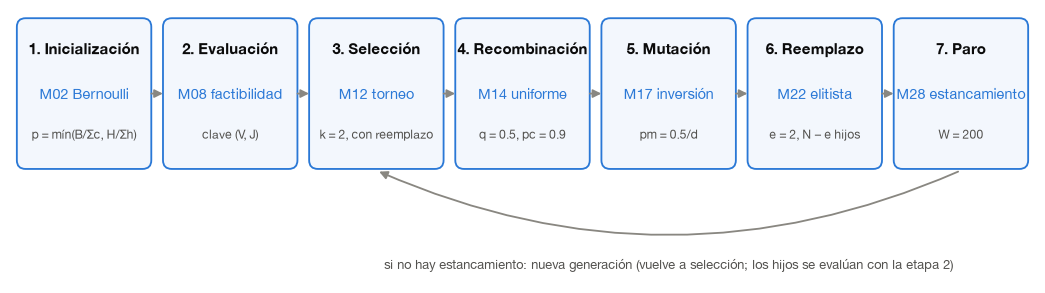

In [22]:
def guardar(fig, nombre):
    fig.savefig(FIGURAS / nombre)
    plt.show()
    plt.close(fig)


# Figura 1 — ciclo de las siete etapas con los métodos elegidos
etapas = [("1", "Inicialización", "M02 Bernoulli", "p = mín(B/Σc, H/Σh)"),
          ("2", "Evaluación", "M08 factibilidad", "clave (V, J)"),
          ("3", "Selección", "M12 torneo", f"k = {CONFIG['k']}, con reemplazo"),
          ("4", "Recombinación", "M14 uniforme", "q = 0.5, pc = 0.9"),
          ("5", "Mutación", "M17 inversión", f"pm = {CONFIG['pm_factor']:g}/d"),
          ("6", "Reemplazo", "M22 elitista", "e = 2, N − e hijos"),
          ("7", "Paro", "M28 estancamiento", f"W = {CONFIG['W']}")]
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.set_xlim(0, 7); ax.set_ylim(-0.75, 1.12); ax.axis("off")
for i, (num, etapa, metodo, detalle_m) in enumerate(etapas):
    caja = FancyBboxPatch((i + 0.06, 0.05), 0.88, 1.0, boxstyle="round,pad=0.02,rounding_size=0.06",
                          linewidth=1.2, edgecolor=AZUL, facecolor="#f3f7fd")
    ax.add_patch(caja)
    ax.text(i + 0.5, 0.86, f"{num}. {etapa}", ha="center", va="center", fontsize=9.5, color=TINTA,
            fontweight="bold")
    ax.text(i + 0.5, 0.55, metodo, ha="center", va="center", fontsize=9.5, color=AZUL)
    ax.text(i + 0.5, 0.27, detalle_m, ha="center", va="center", fontsize=8, color=TINTA_2)
    if i < 6:
        ax.add_patch(FancyArrowPatch((i + 0.94, 0.55), (i + 1.06, 0.55), arrowstyle="-|>",
                                     mutation_scale=11, color=TENUE, linewidth=1.2))
ax.add_patch(FancyArrowPatch((6.5, 0.02), (2.5, 0.02), connectionstyle="arc3,rad=-0.22",
                             arrowstyle="-|>", mutation_scale=11, color=TENUE, linewidth=1.2))
ax.text(4.5, -0.66, "si no hay estancamiento: nueva generación (vuelve a selección; los hijos se evalúan con la etapa 2)",
        ha="center", fontsize=8.5, color=TINTA_2)
guardar(fig, "ae_a03_01_siete_etapas.png")

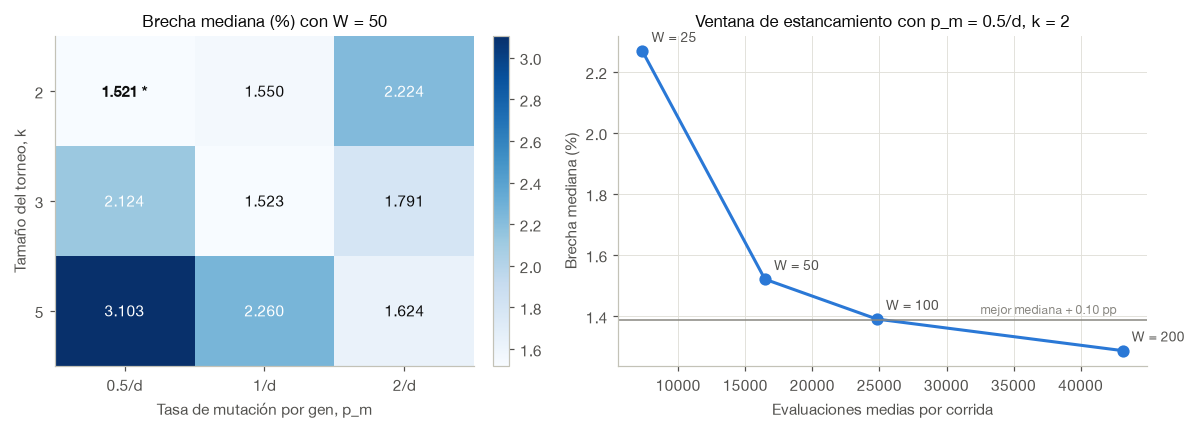

In [23]:
# Figura 2 — calibración: rejilla p_m × k y sensibilidad a W
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={"width_ratios": [1, 1.15]})
matriz = rejilla.pivot(index="k", columns="pm_factor", values="brecha_mediana")
im = a1.imshow(matriz.values, cmap="Blues", aspect="auto")
a1.set_xticks(range(3), [f"{c:g}/d" for c in matriz.columns]); a1.set_yticks(range(3), matriz.index)
a1.set_xlabel("Tasa de mutación por gen, p_m"); a1.set_ylabel("Tamaño del torneo, k"); a1.grid(False)
for (i, j), v in np.ndenumerate(matriz.values):
    elegido = matriz.index[i] == K_TORNEO and matriz.columns[j] == PM_FACTOR
    color = "white" if v > np.nanmean(matriz.values) else TINTA
    a1.text(j, i, f"{v:.3f}" + (" *" if elegido else ""), ha="center", va="center", color=color,
            fontsize=10, fontweight="bold" if elegido else "normal")
a1.set_title("Brecha mediana (%) con W = 50")
fig.colorbar(im, ax=a1, fraction=0.046, pad=0.04)
a2.plot(resumen_w["evaluaciones_media"], resumen_w["brecha_mediana"], "-o", color=AZUL, markersize=7)
for _, f in resumen_w.iterrows():
    a2.annotate(f"W = {int(f['W'])}", (f["evaluaciones_media"], f["brecha_mediana"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9, color=TINTA_2)
a2.axhline(umbral, color=TENUE, linewidth=1)
a2.annotate("mejor mediana + 0.10 pp", (resumen_w["evaluaciones_media"].max(), umbral),
            textcoords="offset points", xytext=(-4, 4), ha="right", fontsize=8, color=TENUE)
a2.set_xlabel("Evaluaciones medias por corrida"); a2.set_ylabel("Brecha mediana (%)")
a2.set_title(f"Ventana de estancamiento con p_m = {PM_FACTOR:g}/d, k = {K_TORNEO}")
fig.tight_layout()
guardar(fig, "ae_a03_02_calibracion.png")

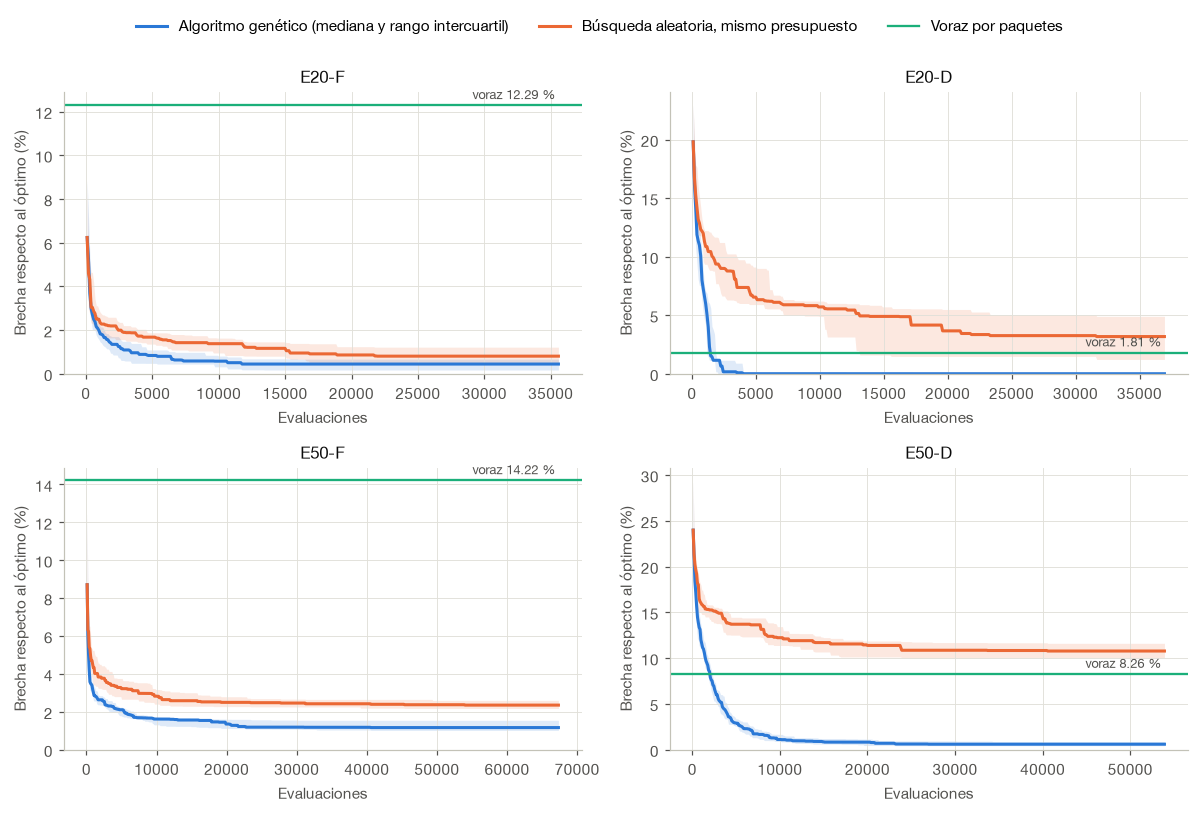

In [24]:
# Figura 3 — convergencia: brecha de la mejor cartera factible frente a evaluaciones
def mediana_por_evaluaciones(df, columna="brecha_pct"):
    tabla = df.pivot_table(index="evaluaciones", columns="semilla", values=columna)
    tabla = tabla.sort_index().ffill()          # tras el paro, cada corrida conserva su valor final
    return tabla.median(axis=1), tabla.quantile(0.25, axis=1), tabla.quantile(0.75, axis=1)

fig, ejes = plt.subplots(2, 2, figsize=(11, 7.2), sharey=False)
for ax, nombre in zip(ejes.ravel(), EVALUACION):
    hist_i = historiales[historiales["instancia"] == nombre]
    ba_i = trayectorias_aleatorias[trayectorias_aleatorias["instancia"] == nombre]
    m, q1, q3 = mediana_por_evaluaciones(hist_i)
    mb, qb1, qb3 = mediana_por_evaluaciones(ba_i)
    ax.fill_between(m.index, q1, q3, color=AZUL, alpha=0.15, linewidth=0)
    ax.plot(m.index, m, color=AZUL, label="Algoritmo genético")
    ax.fill_between(mb.index, qb1, qb3, color=NARANJA, alpha=0.15, linewidth=0)
    ax.plot(mb.index, mb, color=NARANJA, label="Búsqueda aleatoria")
    bv = float(tabla_instancias.set_index("instancia").loc[nombre, "brecha_voraz_pct"])
    ax.axhline(bv, color=AQUA, linewidth=1.5)
    ax.annotate(f"voraz {bv:.2f} %", (m.index.max(), bv), textcoords="offset points", xytext=(-2, 4),
                ha="right", fontsize=8.5, color=TINTA_2)
    ax.set_title(nombre); ax.set_xlabel("Evaluaciones"); ax.set_ylabel("Brecha respecto al óptimo (%)")
    ax.set_ylim(bottom=0)
manijas = [Line2D([], [], color=AZUL, label="Algoritmo genético (mediana y rango intercuartil)"),
           Line2D([], [], color=NARANJA, label="Búsqueda aleatoria, mismo presupuesto"),
           Line2D([], [], color=AQUA, linewidth=1.5, label="Voraz por paquetes")]
fig.legend(handles=manijas, loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.03))
fig.tight_layout(rect=(0, 0, 1, 0.97))
guardar(fig, "ae_a03_03_convergencia.png")

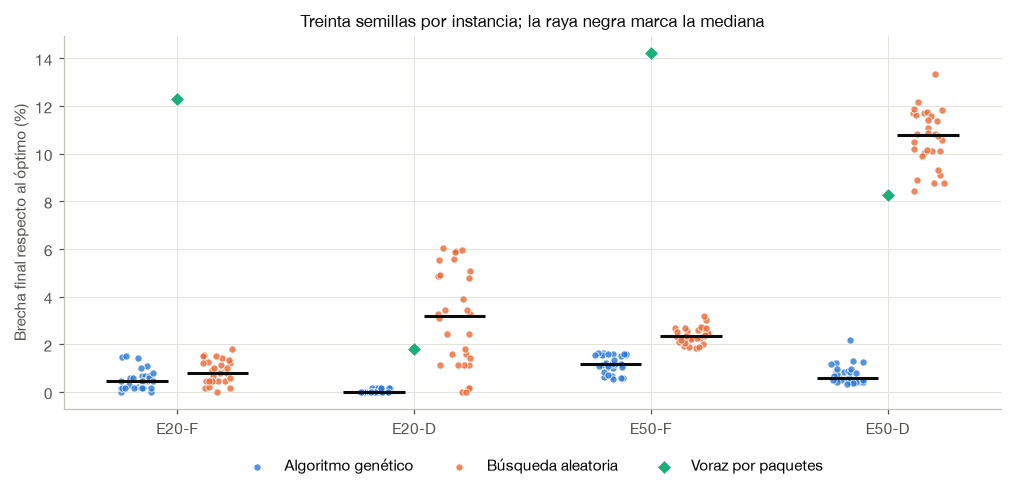

In [25]:
# Figura 4 — brechas finales por semilla
fig, ax = plt.subplots(figsize=(11, 4.4))
rng_vis = np.random.default_rng(0)                  # sólo dispersa los puntos en horizontal
for i, nombre in enumerate(EVALUACION):
    c = corridas[corridas["instancia"] == nombre]
    for desplazamiento, columna, color, etiqueta in ((-0.17, "ag_brecha_pct", AZUL, "Algoritmo genético"),
                                                     (0.17, "ba_brecha_pct", NARANJA, "Búsqueda aleatoria")):
        x = i + desplazamiento + rng_vis.uniform(-0.07, 0.07, len(c))
        ax.scatter(x, c[columna], s=22, color=color, alpha=0.8, edgecolors="white", linewidths=0.6,
                   label=etiqueta if i == 0 else None, zorder=3)
        ax.hlines(c[columna].median(), i + desplazamiento - 0.13, i + desplazamiento + 0.13,
                  color=TINTA, linewidth=2, zorder=4)
    bv = float(tabla_instancias.set_index("instancia").loc[nombre, "brecha_voraz_pct"])
    ax.scatter([i], [bv], marker="D", s=46, color=AQUA, edgecolors="white", linewidths=0.8, zorder=5,
               label="Voraz por paquetes" if i == 0 else None)
ax.set_xticks(range(len(EVALUACION)), EVALUACION)
ax.set_ylabel("Brecha final respecto al óptimo (%)")
ax.set_title("Treinta semillas por instancia; la raya negra marca la mediana")
ax.legend(loc="upper center", ncols=3, bbox_to_anchor=(0.5, -0.09))
guardar(fig, "ae_a03_04_brechas_finales.png")

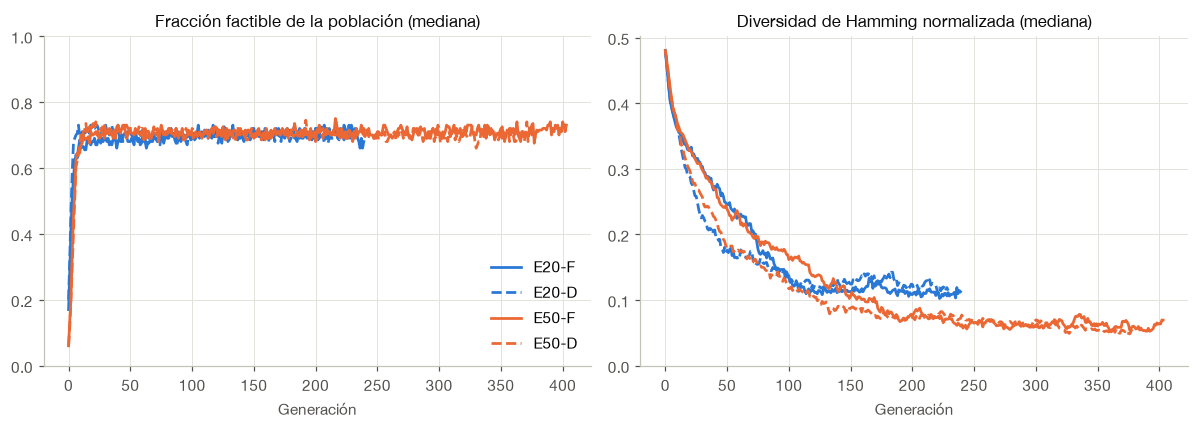

In [26]:
# Figura 5 — factibilidad y diversidad de la población a lo largo de las generaciones.
# Sólo se promedian corridas activas, y se dibuja mientras siga activa al menos la mitad.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))
for nombre, estilo in zip(EVALUACION, ["-", "--", "-", "--"]):
    h = historiales[historiales["instancia"] == nombre]
    color = AZUL if nombre.startswith("E20") else NARANJA
    for ax, columna in ((a1, "fraccion_factible"), (a2, "diversidad")):
        tabla = h.pivot_table(index="generacion", columns="semilla", values=columna)
        activas = tabla.notna().sum(axis=1)
        serie = tabla.median(axis=1)[activas >= len(SEMILLAS) / 2]
        ax.plot(serie.index, serie, linestyle=estilo, color=color, label=nombre, linewidth=1.8)
a1.set_title("Fracción factible de la población (mediana)"); a1.set_xlabel("Generación"); a1.set_ylim(0, 1)
a2.set_title("Diversidad de Hamming normalizada (mediana)"); a2.set_xlabel("Generación"); a2.set_ylim(bottom=0)
a1.legend(loc="lower right")
fig.tight_layout()
guardar(fig, "ae_a03_05_factibilidad_diversidad.png")

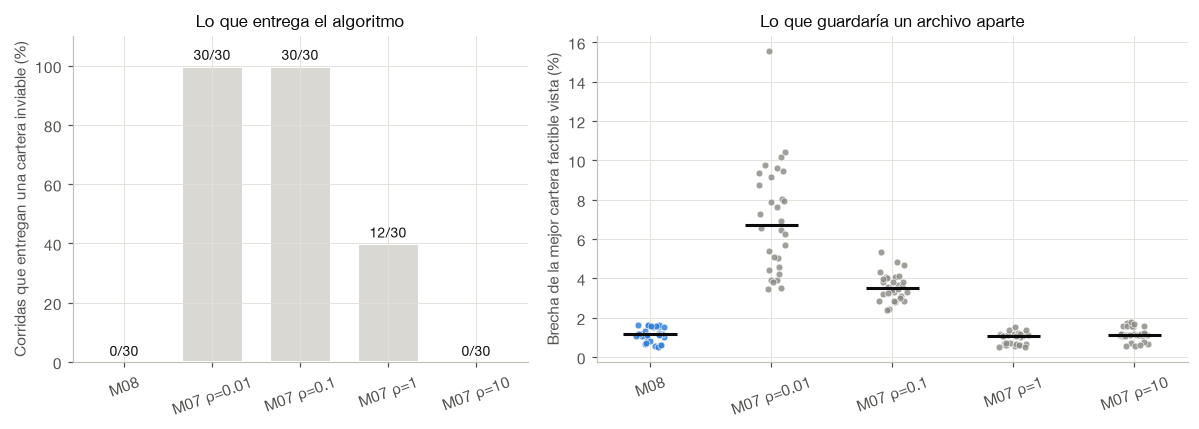

In [27]:
# Figura 6 — ablación de la etapa 2
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={"width_ratios": [1, 1.3]})
orden_cfg = list(resumen_ablacion["configuracion"])
colores = [AZUL if c == "M08" else GRIS_CLARO for c in orden_cfg]
a1.bar(range(len(orden_cfg)), 100 * resumen_ablacion["entregas_inviables"] / len(SEMILLAS), color=colores,
       edgecolor="white", linewidth=2, width=0.7)
for i, v in enumerate(resumen_ablacion["entregas_inviables"]):
    a1.text(i, 100 * v / len(SEMILLAS) + 2, f"{v}/{len(SEMILLAS)}", ha="center", fontsize=9, color=TINTA)
a1.set_xticks(range(len(orden_cfg)), orden_cfg, rotation=20)
a1.set_ylabel("Corridas que entregan una cartera inviable (%)"); a1.set_ylim(0, 110)
a1.set_title("Lo que entrega el algoritmo")
for i, cfg in enumerate(orden_cfg):
    datos = ablacion.loc[ablacion["configuracion"] == cfg, "archivo_brecha_pct"].dropna()
    x = i + rng_vis.uniform(-0.12, 0.12, len(datos))
    a2.scatter(x, datos, s=20, color=AZUL if cfg == "M08" else TENUE, alpha=0.8, edgecolors="white",
               linewidths=0.5, zorder=3)
    a2.hlines(datos.median(), i - 0.22, i + 0.22, color=TINTA, linewidth=2, zorder=4)
a2.set_xticks(range(len(orden_cfg)), orden_cfg, rotation=20)
a2.set_ylabel("Brecha de la mejor cartera factible vista (%)")
a2.set_title("Lo que guardaría un archivo aparte")
fig.tight_layout()
guardar(fig, "ae_a03_06_m07_vs_m08.png")

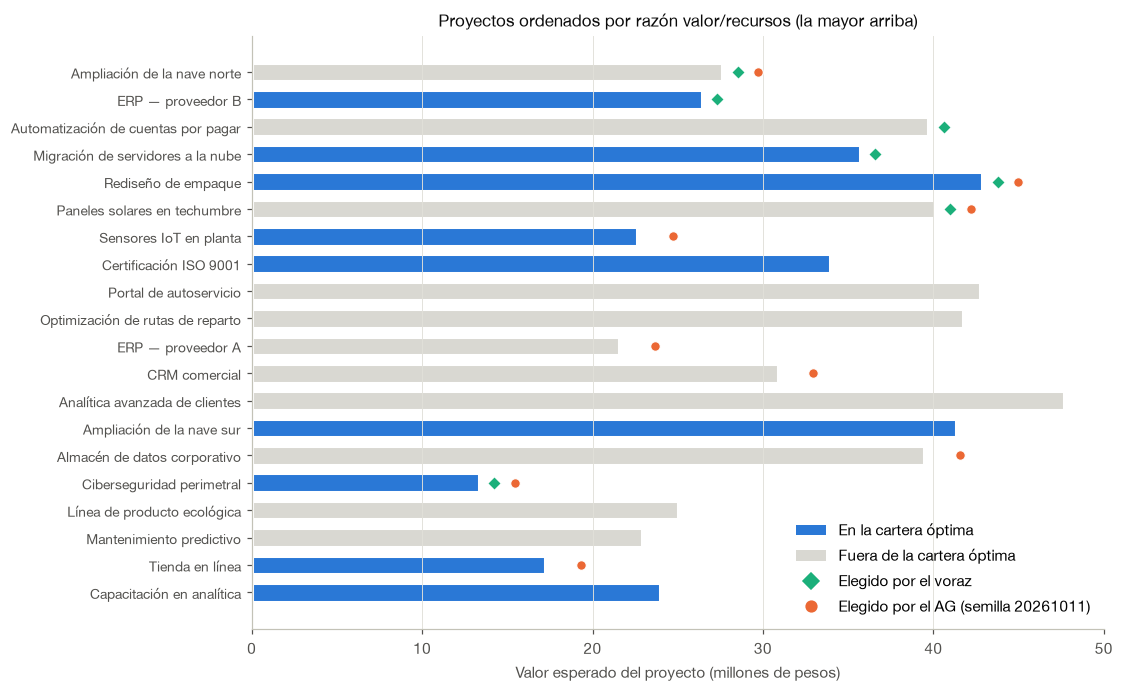

In [28]:
# Figura 7 — la cartera principal, proyecto por proyecto
orden_p = np.argsort(detalle["razon"].to_numpy())
fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(inst_p.d)
valores = detalle["valor_mdp"].to_numpy()[orden_p]
en_optimo = detalle["optimo"].to_numpy()[orden_p] == 1
ax.barh(y, valores, color=np.where(en_optimo, AZUL, GRIS_CLARO), height=0.68, edgecolor="white", linewidth=2)
voraz_sel = detalle["voraz"].to_numpy()[orden_p] == 1
ag_sel = detalle["ag"].to_numpy()[orden_p] == 1
ax.scatter(valores[voraz_sel] + 0.9, y[voraz_sel], marker="D", s=40, color=AQUA, edgecolors="white",
           linewidths=0.8, zorder=4)
ax.scatter(valores[ag_sel] + 2.1, y[ag_sel], marker="o", s=40, color=NARANJA, edgecolors="white",
           linewidths=0.8, zorder=4)
ax.set_yticks(y, [detalle["proyecto"].iloc[j] for j in orden_p], fontsize=9)
ax.set_xlabel("Valor esperado del proyecto (millones de pesos)")
manijas = [Patch(facecolor=AZUL, label="En la cartera óptima"),
           Patch(facecolor=GRIS_CLARO, label="Fuera de la cartera óptima"),
           Line2D([], [], marker="D", linestyle="", color=AQUA, markersize=7, label="Elegido por el voraz"),
           Line2D([], [], marker="o", linestyle="", color=NARANJA, markersize=7,
                  label="Elegido por el AG (semilla 20261011)")]
ax.legend(handles=manijas, loc="lower right")
ax.set_title("Proyectos ordenados por razón valor/recursos (la mayor arriba)")
ax.grid(axis="y", visible=False)
guardar(fig, "ae_a03_07_cartera_principal.png")

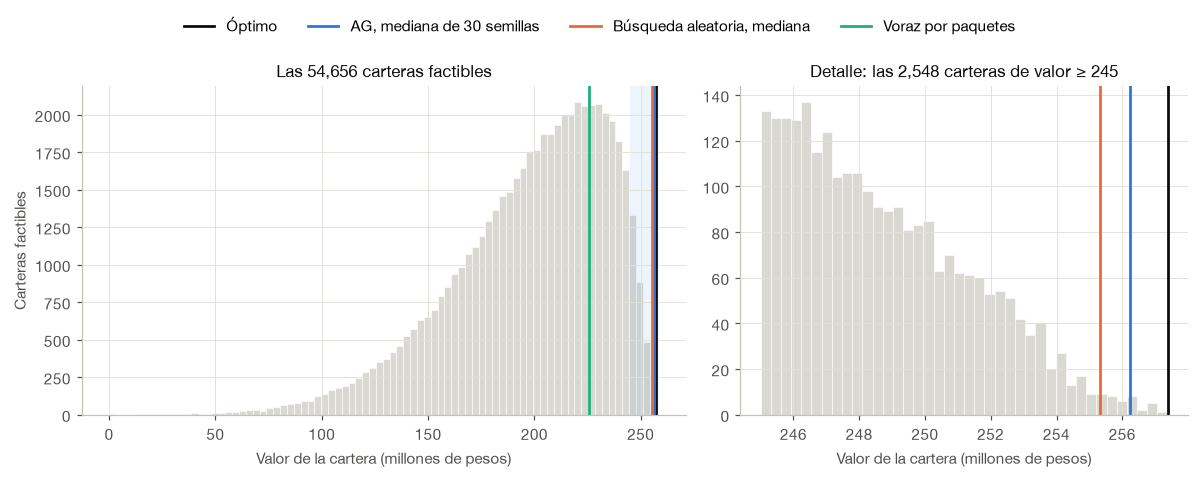

Carteras factibles con valor mayor que la mediana del AG: 11


In [29]:
# Figura 8 — dónde caen las soluciones dentro de todas las carteras factibles de E20-F
vals = en_p["valores_factibles"] / ESCALA_VALOR
cp = corridas[corridas["instancia"] == "E20-F"]
marcas = [("Óptimo", ref_p["optimo"] / ESCALA_VALOR, TINTA),
          ("AG, mediana de 30 semillas", cp["ag_valor"].median() / ESCALA_VALOR, AZUL),
          ("Búsqueda aleatoria, mediana", cp["ba_valor"].median() / ESCALA_VALOR, NARANJA),
          ("Voraz por paquetes", ref_p["voraz"]["valor"] / ESCALA_VALOR, AQUA)]
CORTE_DETALLE = 245.0
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})
a1.hist(vals, bins=80, color=GRIS_CLARO, edgecolor="white", linewidth=0.4)
a1.axvspan(CORTE_DETALLE, vals.max() + 1, color=AZUL, alpha=0.08, linewidth=0)
a1.set_title(f"Las {en_p['factibles']:,} carteras factibles"); a1.set_xlabel("Valor de la cartera (millones de pesos)")
a1.set_ylabel("Carteras factibles")
cola = vals[vals >= CORTE_DETALLE]
a2.hist(cola, bins=40, color=GRIS_CLARO, edgecolor="white", linewidth=0.4)
a2.set_title(f"Detalle: las {len(cola):,} carteras de valor ≥ {CORTE_DETALLE:g}")
a2.set_xlabel("Valor de la cartera (millones de pesos)")
for etiqueta, valor_m, color in marcas:
    for ax in (a1, a2):
        if ax is a1 or valor_m >= CORTE_DETALLE:
            ax.axvline(valor_m, color=color, linewidth=1.8, label=etiqueta if ax is a1 else None)
fig.legend(loc="upper center", ncols=4, bbox_to_anchor=(0.5, 1.04))
fig.tight_layout(rect=(0, 0, 1, 0.95))
guardar(fig, "ae_a03_08_distribucion_factible.png")
print("Carteras factibles con valor mayor que la mediana del AG:",
      int(np.sum(vals > cp["ag_valor"].median() / ESCALA_VALOR)))

## L. Manifiesto de trazabilidad

Versiones, configuración, semillas, conteos y huellas SHA-256 de cada archivo de resultados. Los tiempos dependen del equipo; los valores numéricos no dependen del reloj.

In [30]:
def sha256(ruta: Path) -> str:
    return hashlib.sha256(ruta.read_bytes()).hexdigest()

manifiesto = {
    "fecha_ejecucion": time.strftime("%Y-%m-%d %H:%M:%S"),
    "entorno": {"python": platform.python_version(), "plataforma": platform.platform(),
                "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
                "matplotlib": matplotlib.__version__},
    "configuracion": CONFIG,
    "metodos": {"1": "M02", "2": "M08", "3": "M12", "4": "M14", "5": "M17", "6": "M22", "7": "M28"},
    "semillas_datos": {n: i.semilla for n, i in INSTANCIAS.items()},
    "semillas_calibracion": [SEMILLAS_CALIBRACION[0], SEMILLAS_CALIBRACION[-1]],
    "semillas_evaluacion": [SEMILLAS[0], SEMILLAS[-1]],
    "corridas": {"calibracion": int(len(calibracion) + len(ventanas)), "evaluacion": int(len(corridas)),
                 "ablacion": int(len(ablacion))},
    "evaluaciones_busqueda_evaluacion": int(corridas["evaluaciones"].sum()),
    "pruebas_superadas": len(PRUEBAS),
    "segundos_cuadernillo": time.perf_counter() - INICIO_CUADERNILLO,
    "archivos": {p.name: sha256(p) for p in sorted(RESULTADOS.glob("*.csv"))},
    "figuras": {p.name: sha256(p) for p in sorted(FIGURAS.glob("*.png"))},
}
(RESULTADOS / "manifiesto.json").write_text(json.dumps(manifiesto, ensure_ascii=False, indent=2),
                                            encoding="utf-8")
print(json.dumps({k: v for k, v in manifiesto.items() if k not in ("archivos", "figuras")},
                 ensure_ascii=False, indent=2))

{
  "fecha_ejecucion": "2026-10-07 19:01:29",
  "entorno": {
    "python": "3.11.16",
    "plataforma": "macOS-27.0.1-arm64-arm-64bit",
    "numpy": "2.4.6",
    "pandas": "3.0.6",
    "scipy": "1.17.1",
    "matplotlib": "3.11.2"
  },
  "configuracion": {
    "N": 100,
    "e": 2,
    "pc": 0.9,
    "q": 0.5,
    "pm_factor": 0.5,
    "k": 2,
    "W": 200
  },
  "metodos": {
    "1": "M02",
    "2": "M08",
    "3": "M12",
    "4": "M14",
    "5": "M17",
    "6": "M22",
    "7": "M28"
  },
  "semillas_datos": {
    "C50-F": 20261005,
    "E20-F": 20261006,
    "E20-D": 20261007,
    "E50-F": 20261008,
    "E50-D": 20261009
  },
  "semillas_calibracion": [
    20261100,
    20261109
  ],
  "semillas_evaluacion": [
    20261011,
    20261040
  ],
  "corridas": {
    "calibracion": 130,
    "evaluacion": 120,
    "ablacion": 150
  },
  "evaluaciones_busqueda_evaluacion": 3782060,
  "pruebas_superadas": 13,
  "segundos_cuadernillo": 23.60789916702197
}


## M. Lectura de resultados

Las cifras de esta sección son las de la ejecución registrada en el manifiesto. Las semillas fijan todos los sorteos, de modo que una reejecución con las mismas versiones de bibliotecas reproduce los mismos valores; sólo cambian los tiempos.

**1. Calibración.** La regla eligió $p_m=0.5/d$ y $k=2$, con una brecha mediana de 1.521 % en C50-F. La celda $p_m=1/d$, $k=3$ quedó en 1.523 %: con diez semillas por celda, esa diferencia no distingue a las dos configuraciones, y lo que la calibración sí muestra es qué evitar, que es combinar mutación baja con torneos grandes (3.103 % con $k=5$). Para la ventana, la regla eligió $W=200$, el extremo de la rejilla: pasar de 100 a 200 bajó la brecha mediana de 1.390 % a 1.287 % a cambio de 74 % más evaluaciones. Los rendimientos son decrecientes, y la regla compró calidad porque así se fijó antes de ver los datos.

**2. Calidad frente a las referencias.** Brechas medianas del algoritmo genético: 0.443 % en E20-F, 0.000 % en E20-D, 1.163 % en E50-F y 0.589 % en E50-D. Encontró el óptimo exacto en 23 de 30 corridas de E20-D, en 2 de E20-F y en ninguna de las instancias de cincuenta proyectos. Superó al voraz por paquetes en todas las corridas de las cuatro instancias: el voraz deja brechas de 12.29 %, 1.81 %, 14.22 % y 8.26 %.

**3. La búsqueda aleatoria compite en el caso pequeño y se desploma en el grande.** Con el mismo presupuesto, la búsqueda aleatoria ganó a la corrida genética en 6 de 30 semillas de E20-F. Con unas 23 000 evaluaciones explora el 2 % de un espacio de $2^{20}$ carteras, donde el 5.2 % es factible. En E50-D su brecha mediana fue de 10.77 % contra 0.59 % del algoritmo genético. La prueba de Wilcoxon unilateral favorece al algoritmo genético en las cuatro instancias ($p=0.0034$ en E20-F; $p<10^{-5}$ en las otras tres), pero el **tamaño** de la ventaja depende del problema: es pequeño con veinte proyectos y grande con cincuenta.

**4. El costo del criterio de paro.** Por construcción, M28 gasta $W(N-e)=19\,600$ evaluaciones después de la última mejora. En las instancias de cincuenta proyectos eso es la mitad del presupuesto mediano; en las de veinte, el 84 % al 87 %. La ventana se calibró con cincuenta proyectos y resulta larga para veinte. Es el mismo fenómeno que el artículo modelo observa con M25, sólo que aquí queda como un parámetro explícito y medible.

**5. Ablación de la etapa 2.** Con penalización y $\rho\le 0.1$, las 30 corridas terminan con un individuo inviable como mejor solución: la población migra a carteras que se pasan del presupuesto, porque la penalización no compensa el valor adicional. Con $\rho=1$, 12 de 30 entregan una cartera inviable, aunque un archivo aparte habría guardado buenas carteras factibles (1.062 % de brecha mediana). Sólo con $\rho=10$ la penalización iguala a M08 (1.123 % frente a 1.163 %, con todas las entregas factibles). M08 obtiene esa calidad sin ajustar ningún coeficiente y sin un mecanismo adicional; ésa es la razón de elegirla, y los datos la sostienen.

**6. Caso principal.** La cartera óptima de E20-F reúne nueve proyectos, vale 257.38 millones y usa el 99.87 % del presupuesto y el 99.96 % de las horas: las dos restricciones de recursos están activas. La corrida principal del algoritmo genético obtuvo 255.64 millones (brecha 0.68 %) con otra combinación de nueve proyectos que difiere de la óptima en diez decisiones: cada una tiene cinco proyectos que la otra no. El voraz se quedó en 225.74 millones: agotó el presupuesto con proyectos caros y dejó sin usar el 54 % de las horas. La enumeración muestra que sólo 53 de las 54 656 carteras factibles están a 1 % o menos del óptimo. Que una cartera muy distinta quede a menos de 1 % es información útil para quien decide: hay varias carteras casi equivalentes, y la elección entre ellas puede apoyarse en criterios que el modelo no incluye.

**7. Alcance.** El modelo es lineal con variables binarias, y la programación entera lo resuelve de forma exacta en menos de un segundo en todas las instancias. El algoritmo genético no es aquí la herramienta necesaria: es el objeto de estudio. Tendría sentido práctico si la evaluación dejara de ser lineal, por ejemplo con sinergias entre proyectos, riesgo de la cartera o simulación de escenarios. En ese caso las siete etapas se conservarían y sólo cambiaría la función de la etapa 2.